In [3]:
# ============================================================
# DESCOMPRIMIR LOS DATASETS
# ============================================================

import os
import zipfile

archivo_zip = "/content/data.zip"
carpeta_destino = "/content"

with zipfile.ZipFile(archivo_zip, "r") as zip_ref:
    zip_ref.extractall(carpeta_destino)

print("Archivo descomprimido correctamente.")

Archivo descomprimido correctamente.


In [4]:
# ============================================================
# VERIFICAR ARCHIVOS
# ============================================================

import os

DATA_DIR = "/content/data"

archivos = sorted(os.listdir(DATA_DIR))

print("=" * 70)
print("ARCHIVOS EN /content/data")
print("=" * 70)

for archivo in archivos:
    ruta = os.path.join(DATA_DIR, archivo)
    tam_mb = os.path.getsize(ruta) / (1024**2)

    print(f"{archivo:<40} {tam_mb:8.2f} MB")

print()
print(f"Total de archivos: {len(archivos)}")

ARCHIVOS EN /content/data
ising_dataset_L10.npz                        0.02 MB
ising_dataset_L15.npz                        0.04 MB
ising_dataset_L20.npz                        0.06 MB
ising_dataset_L25.npz                        0.09 MB
ising_dataset_L30.npz                        0.13 MB
temperatura_critica_L10.npz                  0.07 MB
temperatura_critica_L15.npz                  0.15 MB
temperatura_critica_L20.npz                  0.25 MB
temperatura_critica_L25.npz                  0.39 MB
temperatura_critica_L30.npz                  0.55 MB

Total de archivos: 10


In [5]:
# ============================================================
# VERIFICACIÓN COMPLETA DE LOS 10 DATASETS
# ============================================================

import numpy as np
import pandas as pd
import os

DATA_DIR = "/content/data"

Ls = [10, 15, 20, 25, 30]

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

print("=" * 78)
print("AUDITORÍA DE DATASETS — ISING 2D")
print("=" * 78)
print(f"Tc de Onsager = {TC_ONSAGER:.8f}")
print()

filas = []

for L in Ls:

    # --------------------------------------------------------
    # Rutas
    # --------------------------------------------------------
    ruta_train = os.path.join(
        DATA_DIR,
        f"ising_dataset_L{L}.npz"
    )

    ruta_tc = os.path.join(
        DATA_DIR,
        f"temperatura_critica_L{L}.npz"
    )

    # --------------------------------------------------------
    # Cargar archivos
    # --------------------------------------------------------
    train = np.load(ruta_train, allow_pickle=False)
    crit = np.load(ruta_tc, allow_pickle=False)

    # --------------------------------------------------------
    # Dataset de entrenamiento
    # --------------------------------------------------------
    X = train["X"]
    y = train["y"]
    T = train["T"]
    m = train["m"]
    r = train["realizacion"]

    # --------------------------------------------------------
    # Dataset crítico
    # --------------------------------------------------------
    Xtc = crit["X"]
    Ttc = crit["T"]
    mtc = crit["m"]
    rtc = crit["realizacion"]
    yref = crit["y_ref"]

    # --------------------------------------------------------
    # Verificaciones
    # --------------------------------------------------------
    assert X.shape == (1600, L, L)
    assert Xtc.shape == (6200, L, L)

    assert y.shape == (1600,)
    assert T.shape == (1600,)
    assert m.shape == (1600,)
    assert r.shape == (1600,)

    assert Ttc.shape == (6200,)
    assert mtc.shape == (6200,)
    assert rtc.shape == (6200,)
    assert yref.shape == (6200,)

    # Espines solamente ±1
    assert np.all(np.isin(X, [-1, 1]))
    assert np.all(np.isin(Xtc, [-1, 1]))

    # Balance entrenamiento
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())

    assert n0 == 800
    assert n1 == 800

    # Realizaciones
    R_train = len(np.unique(r))
    R_tc = len(np.unique(rtc))

    assert R_train == 4
    assert R_tc == 4

    # Temperaturas
    nT_train = len(np.unique(T))
    nT_tc = len(np.unique(Ttc))

    assert nT_train == 10
    assert nT_tc == 31

    # Magnetización media por fase
    m_ord = m[y == 0].mean()
    m_des = m[y == 1].mean()

    # --------------------------------------------------------
    # Guardar resumen
    # --------------------------------------------------------
    filas.append({
        "L": L,
        "N sitios": L**2,
        "Train": len(X),
        "Crítico": len(Xtc),
        "Clase 0": n0,
        "Clase 1": n1,
        "T train": nT_train,
        "T crítico": nT_tc,
        "R": R_train,
        "|m| ordenada": m_ord,
        "|m| desordenada": m_des
    })

    print(
        f"L={L:2d} | "
        f"train={X.shape} | "
        f"critico={Xtc.shape} | "
        f"clases=[{n0}, {n1}] | "
        f"R={R_train} | OK"
    )

    # Cerrar archivos
    train.close()
    crit.close()


# ============================================================
# TABLA RESUMEN
# ============================================================

resumen = pd.DataFrame(filas)

print()
print("=" * 78)
print("TODOS LOS DATASETS PASARON LAS VERIFICACIONES")
print("=" * 78)

display(
    resumen.round({
        "|m| ordenada": 4,
        "|m| desordenada": 4
    })
)

print()
print("=" * 78)
print("TOTALES")
print("=" * 78)

print(
    f"Configuraciones entrenamiento : "
    f"{resumen['Train'].sum()}"
)

print(
    f"Configuraciones barrido Tc    : "
    f"{resumen['Crítico'].sum()}"
)

print(
    f"Total configuraciones         : "
    f"{resumen['Train'].sum() + resumen['Crítico'].sum()}"
)

AUDITORÍA DE DATASETS — ISING 2D
Tc de Onsager = 2.26918531

L=10 | train=(1600, 10, 10) | critico=(6200, 10, 10) | clases=[800, 800] | R=4 | OK
L=15 | train=(1600, 15, 15) | critico=(6200, 15, 15) | clases=[800, 800] | R=4 | OK
L=20 | train=(1600, 20, 20) | critico=(6200, 20, 20) | clases=[800, 800] | R=4 | OK
L=25 | train=(1600, 25, 25) | critico=(6200, 25, 25) | clases=[800, 800] | R=4 | OK
L=30 | train=(1600, 30, 30) | critico=(6200, 30, 30) | clases=[800, 800] | R=4 | OK

TODOS LOS DATASETS PASARON LAS VERIFICACIONES


,L,N sitios,Train,Crítico,Clase 0,Clase 1,T train,T crítico,R,|m| ordenada,|m| desordenada
0,10,100,1600,6200,800,800,10,31,4,0.9746,0.2818
1,15,225,1600,6200,800,800,10,31,4,0.9760,0.2027
2,20,400,1600,6200,800,800,10,31,4,0.9758,0.1458
3,25,625,1600,6200,800,800,10,31,4,0.9756,0.1211
4,30,900,1600,6200,800,800,10,31,4,0.9754,0.0984



TOTALES
Configuraciones entrenamiento : 8000
Configuraciones barrido Tc    : 31000
Total configuraciones         : 39000


In [6]:
# ============================================================
# PREPARACIÓN TRAIN / VALIDATION / TEST POR REALIZACIÓN
# ============================================================

import numpy as np
import os

DATA_DIR = "/content/data"

Ls = [10, 15, 20, 25, 30]

# Aquí guardaremos los datos preparados para cada L
datasets = {}

print("=" * 78)
print("PARTICIÓN POR REALIZACIÓN")
print("=" * 78)

for L in Ls:

    # --------------------------------------------------------
    # Cargar dataset
    # --------------------------------------------------------

    ruta = os.path.join(
        DATA_DIR,
        f"ising_dataset_L{L}.npz"
    )

    datos = np.load(ruta, allow_pickle=False)

    X = datos["X"].astype(np.float32)
    y = datos["y"].astype(np.int64)
    T = datos["T"].astype(np.float64)
    m = datos["m"].astype(np.float64)
    r = datos["realizacion"].astype(np.int16)

    # --------------------------------------------------------
    # Máscaras por realización
    #
    # r = 0,1 -> entrenamiento
    # r = 2   -> validación
    # r = 3   -> test
    # --------------------------------------------------------

    mask_train = np.isin(r, [0, 1])
    mask_val   = (r == 2)
    mask_test  = (r == 3)

    # --------------------------------------------------------
    # Separación
    # --------------------------------------------------------

    X_train = X[mask_train]
    y_train = y[mask_train]
    T_train = T[mask_train]
    m_train = m[mask_train]

    X_val = X[mask_val]
    y_val = y[mask_val]
    T_val = T[mask_val]
    m_val = m[mask_val]

    X_test = X[mask_test]
    y_test = y[mask_test]
    T_test = T[mask_test]
    m_test = m[mask_test]

    # --------------------------------------------------------
    # Aplanar para MLP
    #
    # (N,L,L) -> (N,L²)
    # --------------------------------------------------------

    X_train_mlp = X_train.reshape(len(X_train), L * L)
    X_val_mlp   = X_val.reshape(len(X_val), L * L)
    X_test_mlp  = X_test.reshape(len(X_test), L * L)

    # --------------------------------------------------------
    # Barajar SOLO dentro de cada conjunto
    # --------------------------------------------------------

    rng = np.random.default_rng(42 + L)

    idx = rng.permutation(len(X_train_mlp))
    X_train_mlp = X_train_mlp[idx]
    y_train = y_train[idx]
    T_train = T_train[idx]
    m_train = m_train[idx]

    idx = rng.permutation(len(X_val_mlp))
    X_val_mlp = X_val_mlp[idx]
    y_val = y_val[idx]
    T_val = T_val[idx]
    m_val = m_val[idx]

    idx = rng.permutation(len(X_test_mlp))
    X_test_mlp = X_test_mlp[idx]
    y_test = y_test[idx]
    T_test = T_test[idx]
    m_test = m_test[idx]

    # --------------------------------------------------------
    # Verificaciones
    # --------------------------------------------------------

    assert len(X_train_mlp) == 800
    assert len(X_val_mlp) == 400
    assert len(X_test_mlp) == 400

    assert X_train_mlp.shape == (800, L * L)
    assert X_val_mlp.shape == (400, L * L)
    assert X_test_mlp.shape == (400, L * L)

    # Cada conjunto debe seguir balanceado
    assert np.array_equal(
        np.bincount(y_train),
        [400, 400]
    )

    assert np.array_equal(
        np.bincount(y_val),
        [200, 200]
    )

    assert np.array_equal(
        np.bincount(y_test),
        [200, 200]
    )

    # --------------------------------------------------------
    # Guardar
    # --------------------------------------------------------

    datasets[L] = {

        "X_train": X_train_mlp,
        "y_train": y_train,
        "T_train": T_train,
        "m_train": m_train,

        "X_val": X_val_mlp,
        "y_val": y_val,
        "T_val": T_val,
        "m_val": m_val,

        "X_test": X_test_mlp,
        "y_test": y_test,
        "T_test": T_test,
        "m_test": m_test
    }

    # --------------------------------------------------------
    # Mostrar resultado
    # --------------------------------------------------------

    print()
    print(f"L = {L}")

    print(
        f"  train : {X_train_mlp.shape}  "
        f"clases={np.bincount(y_train)}"
    )

    print(
        f"  val   : {X_val_mlp.shape}  "
        f"clases={np.bincount(y_val)}"
    )

    print(
        f"  test  : {X_test_mlp.shape}  "
        f"clases={np.bincount(y_test)}"
    )

    datos.close()


print()
print("=" * 78)
print("PARTICIÓN COMPLETADA SIN MEZCLAR REALIZACIONES")
print("=" * 78)

PARTICIÓN POR REALIZACIÓN

L = 10
  train : (800, 100)  clases=[400 400]
  val   : (400, 100)  clases=[200 200]
  test  : (400, 100)  clases=[200 200]

L = 15
  train : (800, 225)  clases=[400 400]
  val   : (400, 225)  clases=[200 200]
  test  : (400, 225)  clases=[200 200]

L = 20
  train : (800, 400)  clases=[400 400]
  val   : (400, 400)  clases=[200 200]
  test  : (400, 400)  clases=[200 200]

L = 25
  train : (800, 625)  clases=[400 400]
  val   : (400, 625)  clases=[200 200]
  test  : (400, 625)  clases=[200 200]

L = 30
  train : (800, 900)  clases=[400 400]
  val   : (400, 900)  clases=[200 200]
  test  : (400, 900)  clases=[200 200]

PARTICIÓN COMPLETADA SIN MEZCLAR REALIZACIONES


# entrenar el MLP para L=10

MLP — MODELO DE ISING 2D — L = 10
X_train : (800, 100)
X_val   : (400, 100)
X_test  : (400, 100)

Train clases : [400 400]
Val clases   : [200 200]
Test clases  : [200 200]

ENTRENANDO...

RESULTADOS
Iteraciones realizadas : 156
Log-loss final         : 0.003307

Accuracy train : 1.0000
Accuracy val   : 0.9750
Accuracy test  : 0.9500

MATRIZ DE CONFUSIÓN — TEST
[[197   3]
 [ 17 183]]

Filas    = clase real
Columnas = clase predicha
0 = ordenada
1 = desordenada

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

    ordenada     0.9206    0.9850    0.9517       200
 desordenada     0.9839    0.9150    0.9482       200

    accuracy                         0.9500       400
   macro avg     0.9522    0.9500    0.9499       400
weighted avg     0.9522    0.9500    0.9499       400



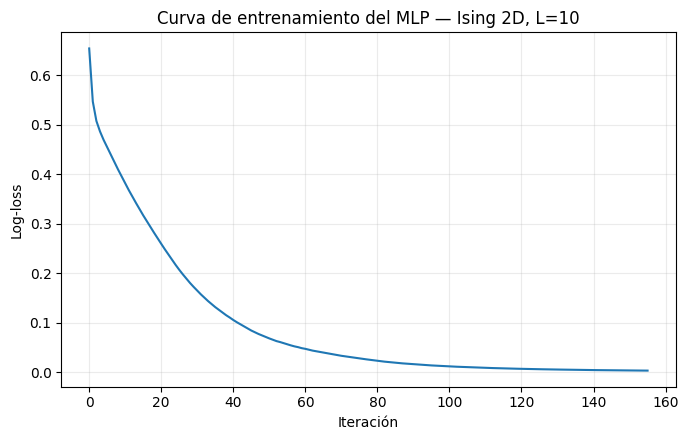

In [7]:
# ============================================================
# MLP — ISING 2D — L = 10
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Seleccionar L = 10
# ------------------------------------------------------------

L_actual = 10

datos_L = datasets[L_actual]

X_train = datos_L["X_train"]
y_train = datos_L["y_train"]

X_val = datos_L["X_val"]
y_val = datos_L["y_val"]

X_test = datos_L["X_test"]
y_test = datos_L["y_test"]

print("=" * 70)
print(f"MLP — MODELO DE ISING 2D — L = {L_actual}")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print(f"Train clases : {np.bincount(y_train)}")
print(f"Val clases   : {np.bincount(y_val)}")
print(f"Test clases  : {np.bincount(y_test)}")


# ------------------------------------------------------------
# 2. Crear MLP
# ------------------------------------------------------------

mlp10 = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# 3. Entrenamiento
# ------------------------------------------------------------

print()
print("=" * 70)
print("ENTRENANDO...")
print("=" * 70)

mlp10.fit(X_train, y_train)


# ------------------------------------------------------------
# 4. Predicciones
# ------------------------------------------------------------

pred_train = mlp10.predict(X_train)
pred_val   = mlp10.predict(X_val)
pred_test  = mlp10.predict(X_test)


# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

acc_train = accuracy_score(y_train, pred_train)
acc_val   = accuracy_score(y_val, pred_val)
acc_test  = accuracy_score(y_test, pred_test)

print()
print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"Iteraciones realizadas : {mlp10.n_iter_}")
print(f"Log-loss final         : {mlp10.loss_:.6f}")

print()
print(f"Accuracy train : {acc_train:.4f}")
print(f"Accuracy val   : {acc_val:.4f}")
print(f"Accuracy test  : {acc_test:.4f}")


# ------------------------------------------------------------
# 6. Matriz de confusión — TEST
# ------------------------------------------------------------

cm = confusion_matrix(y_test, pred_test)

print()
print("=" * 70)
print("MATRIZ DE CONFUSIÓN — TEST")
print("=" * 70)

print(cm)

print()
print("Filas    = clase real")
print("Columnas = clase predicha")
print("0 = ordenada")
print("1 = desordenada")


# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=[
            "ordenada",
            "desordenada"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# 8. Curva de pérdida
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    mlp10.loss_curve_,
    linewidth=1.5
)

plt.xlabel("Iteración")
plt.ylabel("Log-loss")
plt.title(
    "Curva de entrenamiento del MLP — Ising 2D, L=10"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# barrido crítico para L=10

BARRIDO DE TEMPERATURA CRÍTICA — L = 10
X_tc          : (6200, 10, 10)
Temperaturas  : 31
Realizaciones : 4
Rango T       : [1.600, 3.200]
Entrada MLP   : (6200, 100)

ESTIMACIÓN DE LA TEMPERATURA CRÍTICA
Tc Onsager      = 2.269185
Tc MLP (L=10)   = 2.366980
Error absoluto  = 0.097795
Error relativo  = 4.310 %


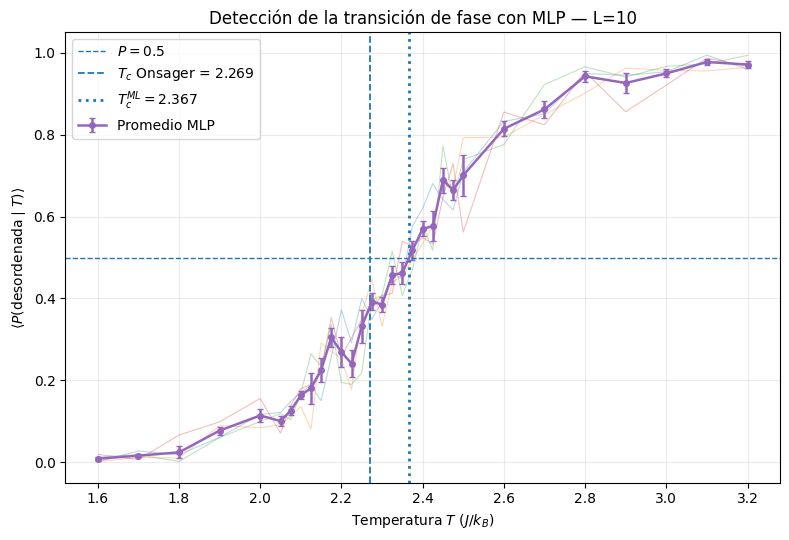


Probabilidades alrededor de la transición:


,T,prob_media,prob_std,prob_sem,m_media,m_sem
8,2.125,0.1810,0.0756,0.0378,0.8685,0.0101
9,2.150,0.2246,0.0578,0.0289,0.8567,0.0064
10,2.175,0.3047,0.0474,0.0237,0.8012,0.0104
11,2.200,0.2690,0.0745,0.0372,0.8128,0.0165
12,2.225,0.2410,0.0662,0.0331,0.8256,0.0158
13,2.250,0.3316,0.0790,0.0395,0.7857,0.0091
14,2.275,0.3926,0.0417,0.0209,0.7686,0.0120
15,2.300,0.3851,0.0361,0.0181,0.7336,0.0084
16,2.325,0.4567,0.0437,0.0219,0.7153,0.0157
17,2.350,0.4625,0.0555,0.0277,0.6947,0.0158


In [8]:
# ============================================================
# ESTIMACIÓN DE Tc CON EL MLP — L = 10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L_actual = 10

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Cargar dataset de temperatura crítica
# ------------------------------------------------------------

ruta_tc = os.path.join(
    DATA_DIR,
    f"temperatura_critica_L{L_actual}.npz"
)

datos_tc = np.load(ruta_tc, allow_pickle=False)

X_tc = datos_tc["X"].astype(np.float32)
T_tc = datos_tc["T"].astype(np.float64)
r_tc = datos_tc["realizacion"].astype(np.int16)
m_tc = datos_tc["m"].astype(np.float64)

print("=" * 72)
print(f"BARRIDO DE TEMPERATURA CRÍTICA — L = {L_actual}")
print("=" * 72)

print(f"X_tc          : {X_tc.shape}")
print(f"Temperaturas  : {len(np.unique(T_tc))}")
print(f"Realizaciones : {len(np.unique(r_tc))}")
print(
    f"Rango T       : "
    f"[{T_tc.min():.3f}, {T_tc.max():.3f}]"
)

# ------------------------------------------------------------
# 2. Aplanar configuraciones para el MLP
# ------------------------------------------------------------

X_tc_mlp = X_tc.reshape(
    len(X_tc),
    L_actual * L_actual
)

print(f"Entrada MLP   : {X_tc_mlp.shape}")


# ------------------------------------------------------------
# 3. Probabilidad de fase desordenada
#
# predict_proba:
# columna 0 -> P(y=0) ordenada
# columna 1 -> P(y=1) desordenada
# ------------------------------------------------------------

p_desordenada = mlp10.predict_proba(X_tc_mlp)[:, 1]


# ------------------------------------------------------------
# 4. DataFrame
# ------------------------------------------------------------

df_tc10 = pd.DataFrame({
    "T": T_tc,
    "realizacion": r_tc,
    "prob": p_desordenada,
    "m": m_tc
})


# ------------------------------------------------------------
# 5. Promedio primero dentro de cada realización
# ------------------------------------------------------------

por_realizacion = (
    df_tc10
    .groupby(["realizacion", "T"], as_index=False)
    .agg(
        prob=("prob", "mean"),
        m=("m", "mean")
    )
)


# ------------------------------------------------------------
# 6. Promedio entre realizaciones
# ------------------------------------------------------------

promedio_tc10 = (
    por_realizacion
    .groupby("T", as_index=False)
    .agg(
        prob_media=("prob", "mean"),
        prob_std=("prob", "std"),
        prob_sem=("prob", "sem"),
        m_media=("m", "mean"),
        m_sem=("m", "sem")
    )
    .sort_values("T")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Buscar cruce P = 0.5 mediante interpolación lineal
# ------------------------------------------------------------

Tvals = promedio_tc10["T"].to_numpy()
Pvals = promedio_tc10["prob_media"].to_numpy()

cruces = []

for i in range(len(Tvals) - 1):

    p1 = Pvals[i]
    p2 = Pvals[i + 1]

    if (p1 - 0.5) * (p2 - 0.5) <= 0 and p1 != p2:

        T1 = Tvals[i]
        T2 = Tvals[i + 1]

        Tc_ml = (
            T1
            + (0.5 - p1)
            * (T2 - T1)
            / (p2 - p1)
        )

        cruces.append(Tc_ml)


if len(cruces) == 0:

    Tc_ml_10 = np.nan
    print("\nNo se encontró cruce con P = 0.5.")

else:

    # Si hubiera más de un cruce por ruido,
    # escogemos el más cercano a la zona crítica de Onsager.
    Tc_ml_10 = min(
        cruces,
        key=lambda x: abs(x - TC_ONSAGER)
    )


# ------------------------------------------------------------
# 8. Resultados numéricos
# ------------------------------------------------------------

print()
print("=" * 72)
print("ESTIMACIÓN DE LA TEMPERATURA CRÍTICA")
print("=" * 72)

print(f"Tc Onsager      = {TC_ONSAGER:.6f}")

if np.isfinite(Tc_ml_10):

    error_abs = abs(Tc_ml_10 - TC_ONSAGER)

    error_rel = (
        error_abs / TC_ONSAGER
    ) * 100

    print(f"Tc MLP (L=10)   = {Tc_ml_10:.6f}")
    print(f"Error absoluto  = {error_abs:.6f}")
    print(f"Error relativo  = {error_rel:.3f} %")

else:

    print("Tc MLP (L=10)   = no encontrado")


# ------------------------------------------------------------
# 9. Gráfica P(desordenada | T)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Realizaciones individuales
for r, sub in por_realizacion.groupby("realizacion"):

    sub = sub.sort_values("T")

    ax.plot(
        sub["T"],
        sub["prob"],
        "-",
        lw=0.8,
        alpha=0.30
    )


# Promedio + error estándar
ax.errorbar(
    promedio_tc10["T"],
    promedio_tc10["prob_media"],
    yerr=promedio_tc10["prob_sem"],
    fmt="o-",
    lw=1.8,
    ms=4,
    capsize=2,
    label="Promedio MLP"
)


# P = 0.5
ax.axhline(
    0.5,
    ls="--",
    lw=1,
    label=r"$P=0.5$"
)


# Tc exacta
ax.axvline(
    TC_ONSAGER,
    ls="--",
    lw=1.3,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.3f}"
)


# Tc estimada por ML
if np.isfinite(Tc_ml_10):

    ax.axvline(
        Tc_ml_10,
        ls=":",
        lw=2,
        label=fr"$T_c^{{ML}}={Tc_ml_10:.3f}$"
    )


ax.set_xlabel(
    r"Temperatura $T$ ($J/k_B$)"
)

ax.set_ylabel(
    r"$\langle P(\mathrm{desordenada}\mid T)\rangle$"
)

ax.set_title(
    "Detección de la transición de fase con MLP — L=10"
)

ax.set_ylim(-0.05, 1.05)

ax.grid(alpha=0.25)

ax.legend()

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# 10. Mostrar valores alrededor de Tc
# ------------------------------------------------------------

zona_critica = promedio_tc10[
    (promedio_tc10["T"] >= 2.10)
    &
    (promedio_tc10["T"] <= 2.45)
]

print()
print("Probabilidades alrededor de la transición:")
display(zona_critica.round(4))


datos_tc.close()

# MLP — ISING 2D — L = 15

MLP — MODELO DE ISING 2D — L = 15
X_train : (800, 225)
X_val   : (400, 225)
X_test  : (400, 225)

Train clases : [400 400]
Val clases   : [200 200]
Test clases  : [200 200]

ENTRENANDO...

RESULTADOS
Iteraciones realizadas : 107
Log-loss final         : 0.003718

Accuracy train : 1.0000
Accuracy val   : 0.9850
Accuracy test  : 0.9800

MATRIZ DE CONFUSIÓN — TEST
[[200   0]
 [  8 192]]

Filas    = clase real
Columnas = clase predicha
0 = ordenada
1 = desordenada

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

    ordenada     0.9615    1.0000    0.9804       200
 desordenada     1.0000    0.9600    0.9796       200

    accuracy                         0.9800       400
   macro avg     0.9808    0.9800    0.9800       400
weighted avg     0.9808    0.9800    0.9800       400



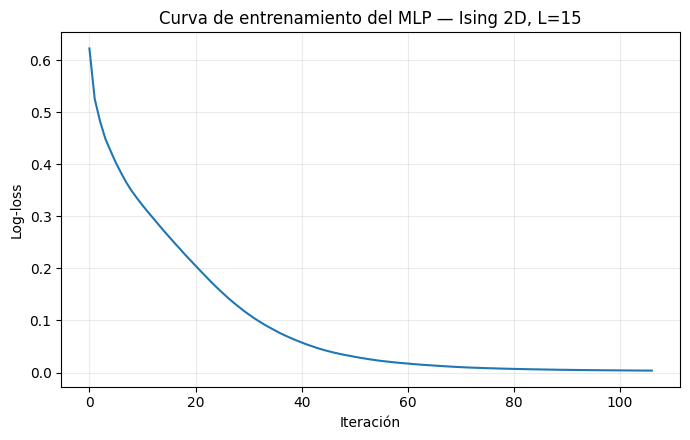

In [9]:
# ============================================================
# MLP — ISING 2D — L = 15
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Seleccionar L = 15
# ------------------------------------------------------------

L_actual = 15

datos_L = datasets[L_actual]

X_train = datos_L["X_train"]
y_train = datos_L["y_train"]

X_val = datos_L["X_val"]
y_val = datos_L["y_val"]

X_test = datos_L["X_test"]
y_test = datos_L["y_test"]

print("=" * 70)
print(f"MLP — MODELO DE ISING 2D — L = {L_actual}")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print(f"Train clases : {np.bincount(y_train)}")
print(f"Val clases   : {np.bincount(y_val)}")
print(f"Test clases  : {np.bincount(y_test)}")


# ------------------------------------------------------------
# 2. Crear MLP
# ------------------------------------------------------------

mlp15 = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# 3. Entrenar
# ------------------------------------------------------------

print()
print("=" * 70)
print("ENTRENANDO...")
print("=" * 70)

mlp15.fit(X_train, y_train)


# ------------------------------------------------------------
# 4. Predicciones
# ------------------------------------------------------------

pred_train = mlp15.predict(X_train)
pred_val   = mlp15.predict(X_val)
pred_test  = mlp15.predict(X_test)


# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

acc_train15 = accuracy_score(y_train, pred_train)
acc_val15   = accuracy_score(y_val, pred_val)
acc_test15  = accuracy_score(y_test, pred_test)

print()
print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"Iteraciones realizadas : {mlp15.n_iter_}")
print(f"Log-loss final         : {mlp15.loss_:.6f}")

print()
print(f"Accuracy train : {acc_train15:.4f}")
print(f"Accuracy val   : {acc_val15:.4f}")
print(f"Accuracy test  : {acc_test15:.4f}")


# ------------------------------------------------------------
# 6. Matriz de confusión
# ------------------------------------------------------------

cm15 = confusion_matrix(y_test, pred_test)

print()
print("=" * 70)
print("MATRIZ DE CONFUSIÓN — TEST")
print("=" * 70)

print(cm15)

print()
print("Filas    = clase real")
print("Columnas = clase predicha")
print("0 = ordenada")
print("1 = desordenada")


# ------------------------------------------------------------
# 7. Classification report
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_test,
        target_names=[
            "ordenada",
            "desordenada"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# 8. Curva de pérdida
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    mlp15.loss_curve_,
    linewidth=1.5
)

plt.xlabel("Iteración")
plt.ylabel("Log-loss")

plt.title(
    "Curva de entrenamiento del MLP — Ising 2D, L=15"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ESTIMACIÓN DE Tc CON EL MLP — L = 15

BARRIDO DE TEMPERATURA CRÍTICA — L = 15
X_tc          : (6200, 15, 15)
Temperaturas  : 31
Realizaciones : 4
Rango T       : [1.600, 3.200]
Entrada MLP   : (6200, 225)

ESTIMACIÓN DE LA TEMPERATURA CRÍTICA
Tc Onsager      = 2.269185
Tc MLP (L=15)   = 2.355936
Error absoluto  = 0.086750
Error relativo  = 3.823 %


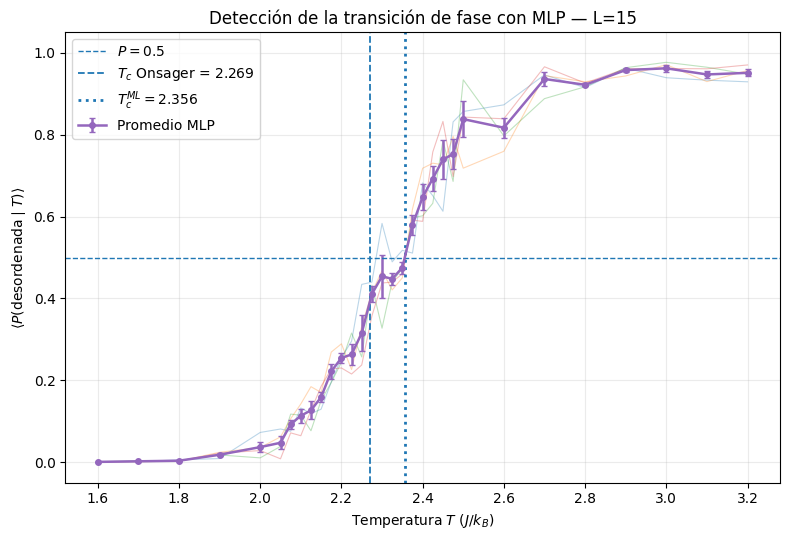


Probabilidades alrededor de la transición:


,T,prob_media,prob_std,prob_sem,m_media,m_sem
8,2.125,0.1267,0.0443,0.0221,0.8611,0.0077
9,2.150,0.1591,0.0242,0.0121,0.8443,0.0010
10,2.175,0.2219,0.0349,0.0175,0.8192,0.0071
11,2.200,0.2547,0.0252,0.0126,0.7895,0.0151
12,2.225,0.2633,0.0497,0.0249,0.7832,0.0112
13,2.250,0.3154,0.0892,0.0446,0.7641,0.0241
14,2.275,0.4110,0.0374,0.0187,0.7096,0.0134
15,2.300,0.4541,0.1052,0.0526,0.6581,0.0253
16,2.325,0.4479,0.0293,0.0146,0.6678,0.0196
17,2.350,0.4753,0.0297,0.0148,0.6275,0.0217


In [10]:
# ============================================================
# ESTIMACIÓN DE Tc CON EL MLP — L = 15
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L_actual = 15

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Cargar dataset crítico
# ------------------------------------------------------------

ruta_tc = os.path.join(
    DATA_DIR,
    f"temperatura_critica_L{L_actual}.npz"
)

datos_tc = np.load(ruta_tc, allow_pickle=False)

X_tc = datos_tc["X"].astype(np.float32)
T_tc = datos_tc["T"].astype(np.float64)
r_tc = datos_tc["realizacion"].astype(np.int16)
m_tc = datos_tc["m"].astype(np.float64)

print("=" * 72)
print(f"BARRIDO DE TEMPERATURA CRÍTICA — L = {L_actual}")
print("=" * 72)

print(f"X_tc          : {X_tc.shape}")
print(f"Temperaturas  : {len(np.unique(T_tc))}")
print(f"Realizaciones : {len(np.unique(r_tc))}")
print(f"Rango T       : [{T_tc.min():.3f}, {T_tc.max():.3f}]")


# ------------------------------------------------------------
# 2. Preparar entrada para MLP
# ------------------------------------------------------------

X_tc_mlp = X_tc.reshape(
    len(X_tc),
    L_actual * L_actual
)

print(f"Entrada MLP   : {X_tc_mlp.shape}")


# ------------------------------------------------------------
# 3. Probabilidad P(y=1) = P(desordenada)
# ------------------------------------------------------------

p_desordenada = mlp15.predict_proba(X_tc_mlp)[:, 1]


# ------------------------------------------------------------
# 4. DataFrame
# ------------------------------------------------------------

df_tc15 = pd.DataFrame({
    "T": T_tc,
    "realizacion": r_tc,
    "prob": p_desordenada,
    "m": m_tc
})


# ------------------------------------------------------------
# 5. Promedio dentro de cada realización
# ------------------------------------------------------------

por_realizacion15 = (
    df_tc15
    .groupby(["realizacion", "T"], as_index=False)
    .agg(
        prob=("prob", "mean"),
        m=("m", "mean")
    )
)


# ------------------------------------------------------------
# 6. Promedio entre las cuatro realizaciones
# ------------------------------------------------------------

promedio_tc15 = (
    por_realizacion15
    .groupby("T", as_index=False)
    .agg(
        prob_media=("prob", "mean"),
        prob_std=("prob", "std"),
        prob_sem=("prob", "sem"),
        m_media=("m", "mean"),
        m_sem=("m", "sem")
    )
    .sort_values("T")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. Interpolación lineal del cruce P = 0.5
# ------------------------------------------------------------

Tvals = promedio_tc15["T"].to_numpy()
Pvals = promedio_tc15["prob_media"].to_numpy()

cruces = []

for i in range(len(Tvals) - 1):

    p1 = Pvals[i]
    p2 = Pvals[i + 1]

    if (p1 - 0.5) * (p2 - 0.5) <= 0 and p1 != p2:

        T1 = Tvals[i]
        T2 = Tvals[i + 1]

        Tc_cruce = (
            T1
            + (0.5 - p1)
            * (T2 - T1)
            / (p2 - p1)
        )

        cruces.append(Tc_cruce)


if len(cruces) > 0:

    Tc_ml_15 = min(
        cruces,
        key=lambda x: abs(x - TC_ONSAGER)
    )

else:

    Tc_ml_15 = np.nan


# ------------------------------------------------------------
# 8. Error
# ------------------------------------------------------------

print()
print("=" * 72)
print("ESTIMACIÓN DE LA TEMPERATURA CRÍTICA")
print("=" * 72)

print(f"Tc Onsager      = {TC_ONSAGER:.6f}")

if np.isfinite(Tc_ml_15):

    error_abs_15 = abs(
        Tc_ml_15 - TC_ONSAGER
    )

    error_rel_15 = (
        error_abs_15 / TC_ONSAGER
    ) * 100

    print(f"Tc MLP (L=15)   = {Tc_ml_15:.6f}")
    print(f"Error absoluto  = {error_abs_15:.6f}")
    print(f"Error relativo  = {error_rel_15:.3f} %")

else:

    print("No se encontró cruce con P = 0.5.")


# ------------------------------------------------------------
# 9. Gráfica
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Realizaciones individuales
for r, sub in por_realizacion15.groupby("realizacion"):

    sub = sub.sort_values("T")

    ax.plot(
        sub["T"],
        sub["prob"],
        "-",
        lw=0.8,
        alpha=0.30
    )


# Promedio
ax.errorbar(
    promedio_tc15["T"],
    promedio_tc15["prob_media"],
    yerr=promedio_tc15["prob_sem"],
    fmt="o-",
    lw=1.8,
    ms=4,
    capsize=2,
    label="Promedio MLP"
)


# Línea P = 0.5
ax.axhline(
    0.5,
    ls="--",
    lw=1,
    label=r"$P=0.5$"
)


# Onsager
ax.axvline(
    TC_ONSAGER,
    ls="--",
    lw=1.3,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.3f}"
)


# Tc MLP
if np.isfinite(Tc_ml_15):

    ax.axvline(
        Tc_ml_15,
        ls=":",
        lw=2,
        label=fr"$T_c^{{ML}}={Tc_ml_15:.3f}$"
    )


ax.set_xlabel(
    r"Temperatura $T$ ($J/k_B$)"
)

ax.set_ylabel(
    r"$\langle P(\mathrm{desordenada}\mid T)\rangle$"
)

ax.set_title(
    "Detección de la transición de fase con MLP — L=15"
)

ax.set_ylim(-0.05, 1.05)

ax.grid(alpha=0.25)

ax.legend()

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Tabla alrededor de Tc
# ------------------------------------------------------------

zona_critica15 = promedio_tc15[
    (promedio_tc15["T"] >= 2.10)
    &
    (promedio_tc15["T"] <= 2.45)
]

print()
print("Probabilidades alrededor de la transición:")

display(
    zona_critica15.round(4)
)

datos_tc.close()

# MLP — ISING 2D — L = 20

MLP — MODELO DE ISING 2D — L = 20
X_train : (800, 400)
X_val   : (400, 400)
X_test  : (400, 400)

Train clases : [400 400]
Val clases   : [200 200]
Test clases  : [200 200]

ENTRENANDO...

RESULTADOS
Iteraciones realizadas : 103
Log-loss final         : 0.002462

Accuracy train : 1.0000
Accuracy val   : 0.9875
Accuracy test  : 0.9775

MATRIZ DE CONFUSIÓN — TEST
[[200   0]
 [  9 191]]

Filas    = clase real
Columnas = clase predicha
0 = ordenada
1 = desordenada

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

    ordenada     0.9569    1.0000    0.9780       200
 desordenada     1.0000    0.9550    0.9770       200

    accuracy                         0.9775       400
   macro avg     0.9785    0.9775    0.9775       400
weighted avg     0.9785    0.9775    0.9775       400



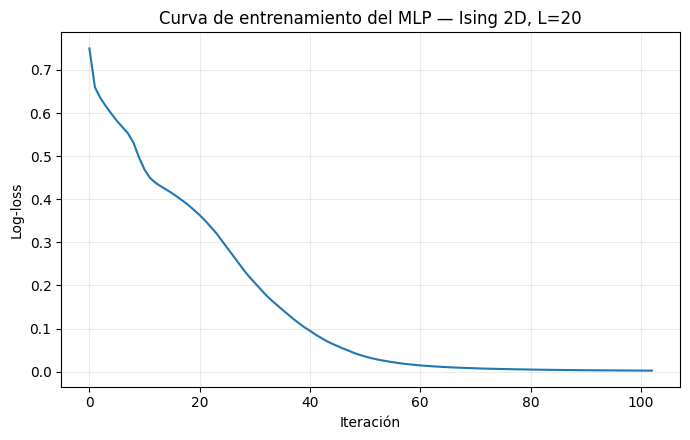

In [11]:
# ============================================================
# MLP — ISING 2D — L = 20
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Seleccionar L = 20
# ------------------------------------------------------------

L_actual = 20

datos_L = datasets[L_actual]

X_train = datos_L["X_train"]
y_train = datos_L["y_train"]

X_val = datos_L["X_val"]
y_val = datos_L["y_val"]

X_test = datos_L["X_test"]
y_test = datos_L["y_test"]

print("=" * 70)
print(f"MLP — MODELO DE ISING 2D — L = {L_actual}")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print(f"Train clases : {np.bincount(y_train)}")
print(f"Val clases   : {np.bincount(y_val)}")
print(f"Test clases  : {np.bincount(y_test)}")


# ------------------------------------------------------------
# 2. Crear MLP
# ------------------------------------------------------------

mlp20 = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# 3. Entrenar
# ------------------------------------------------------------

print()
print("=" * 70)
print("ENTRENANDO...")
print("=" * 70)

mlp20.fit(X_train, y_train)


# ------------------------------------------------------------
# 4. Predicciones
# ------------------------------------------------------------

pred_train20 = mlp20.predict(X_train)
pred_val20   = mlp20.predict(X_val)
pred_test20  = mlp20.predict(X_test)


# ------------------------------------------------------------
# 5. Accuracy
# ------------------------------------------------------------

acc_train20 = accuracy_score(y_train, pred_train20)
acc_val20   = accuracy_score(y_val, pred_val20)
acc_test20  = accuracy_score(y_test, pred_test20)

print()
print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"Iteraciones realizadas : {mlp20.n_iter_}")
print(f"Log-loss final         : {mlp20.loss_:.6f}")

print()
print(f"Accuracy train : {acc_train20:.4f}")
print(f"Accuracy val   : {acc_val20:.4f}")
print(f"Accuracy test  : {acc_test20:.4f}")


# ------------------------------------------------------------
# 6. Matriz de confusión
# ------------------------------------------------------------

cm20 = confusion_matrix(y_test, pred_test20)

print()
print("=" * 70)
print("MATRIZ DE CONFUSIÓN — TEST")
print("=" * 70)

print(cm20)

print()
print("Filas    = clase real")
print("Columnas = clase predicha")
print("0 = ordenada")
print("1 = desordenada")


# ------------------------------------------------------------
# 7. Reporte
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_test20,
        target_names=["ordenada", "desordenada"],
        digits=4
    )
)


# ------------------------------------------------------------
# 8. Curva de pérdida
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    mlp20.loss_curve_,
    linewidth=1.5
)

plt.xlabel("Iteración")
plt.ylabel("Log-loss")

plt.title(
    "Curva de entrenamiento del MLP — Ising 2D, L=20"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# # ESTIMACIÓN DE Tc CON EL MLP — L = 20

BARRIDO DE TEMPERATURA CRÍTICA — L = 20
X_tc          : (6200, 20, 20)
Temperaturas  : 31
Realizaciones : 4
Rango T       : [1.600, 3.200]
Entrada MLP   : (6200, 400)

ESTIMACIÓN DE LA TEMPERATURA CRÍTICA
Tc Onsager      = 2.269185
Tc MLP (L=20)   = 2.352578
Error absoluto  = 0.083392
Error relativo  = 3.675 %


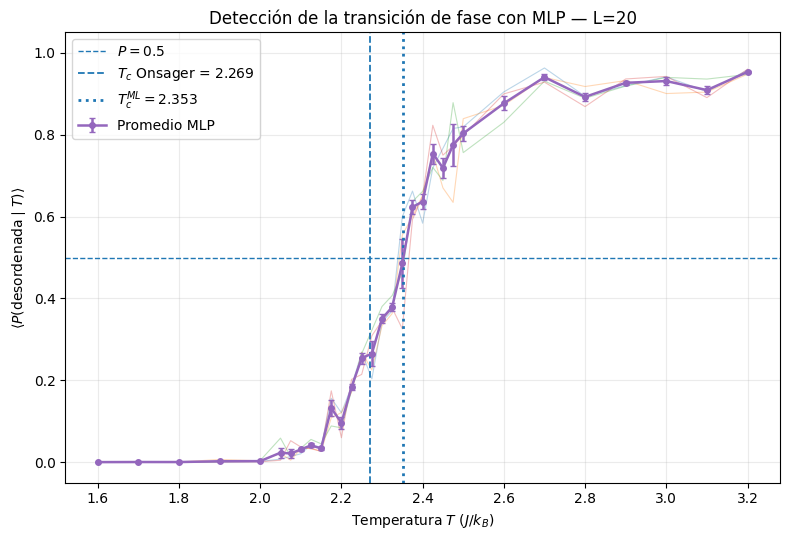


Probabilidades alrededor de la transición:


,T,prob_media,prob_std,prob_sem,m_media,m_sem
8,2.125,0.0413,0.0105,0.0052,0.8523,0.0079
9,2.150,0.0338,0.0089,0.0045,0.8418,0.0035
10,2.175,0.1320,0.0400,0.0200,0.8027,0.0149
11,2.200,0.0965,0.0300,0.0150,0.8084,0.0105
12,2.225,0.1837,0.0139,0.0069,0.7649,0.0079
13,2.250,0.2545,0.0266,0.0133,0.7067,0.0055
14,2.275,0.2653,0.0594,0.0297,0.7023,0.0137
15,2.300,0.3507,0.0206,0.0103,0.6636,0.0159
16,2.325,0.3791,0.0194,0.0097,0.6143,0.0140
17,2.350,0.4858,0.1210,0.0605,0.5494,0.0313


In [12]:
# ============================================================
# ESTIMACIÓN DE Tc CON EL MLP — L = 20
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L_actual = 20
TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Cargar dataset de temperatura crítica
# ------------------------------------------------------------

ruta_tc = os.path.join(
    DATA_DIR,
    f"temperatura_critica_L{L_actual}.npz"
)

datos_tc = np.load(ruta_tc, allow_pickle=False)

X_tc = datos_tc["X"].astype(np.float32)
T_tc = datos_tc["T"].astype(np.float64)
r_tc = datos_tc["realizacion"].astype(np.int16)
m_tc = datos_tc["m"].astype(np.float64)

print("=" * 72)
print(f"BARRIDO DE TEMPERATURA CRÍTICA — L = {L_actual}")
print("=" * 72)

print(f"X_tc          : {X_tc.shape}")
print(f"Temperaturas  : {len(np.unique(T_tc))}")
print(f"Realizaciones : {len(np.unique(r_tc))}")
print(f"Rango T       : [{T_tc.min():.3f}, {T_tc.max():.3f}]")

# ------------------------------------------------------------
# 2. Aplanar para el MLP
# ------------------------------------------------------------

X_tc_mlp = X_tc.reshape(
    len(X_tc),
    L_actual * L_actual
)

print(f"Entrada MLP   : {X_tc_mlp.shape}")

# ------------------------------------------------------------
# 3. Probabilidad de fase desordenada
# ------------------------------------------------------------

p_desordenada = mlp20.predict_proba(X_tc_mlp)[:, 1]

# ------------------------------------------------------------
# 4. DataFrame
# ------------------------------------------------------------

df_tc20 = pd.DataFrame({
    "T": T_tc,
    "realizacion": r_tc,
    "prob": p_desordenada,
    "m": m_tc
})

# ------------------------------------------------------------
# 5. Promedio por realización y temperatura
# ------------------------------------------------------------

por_realizacion20 = (
    df_tc20
    .groupby(["realizacion", "T"], as_index=False)
    .agg(
        prob=("prob", "mean"),
        m=("m", "mean")
    )
)

# ------------------------------------------------------------
# 6. Promedio entre realizaciones
# ------------------------------------------------------------

promedio_tc20 = (
    por_realizacion20
    .groupby("T", as_index=False)
    .agg(
        prob_media=("prob", "mean"),
        prob_std=("prob", "std"),
        prob_sem=("prob", "sem"),
        m_media=("m", "mean"),
        m_sem=("m", "sem")
    )
    .sort_values("T")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Interpolación lineal para P = 0.5
# ------------------------------------------------------------

Tvals = promedio_tc20["T"].to_numpy()
Pvals = promedio_tc20["prob_media"].to_numpy()

cruces = []

for i in range(len(Tvals) - 1):

    p1 = Pvals[i]
    p2 = Pvals[i + 1]

    if (p1 - 0.5) * (p2 - 0.5) <= 0 and p1 != p2:

        T1 = Tvals[i]
        T2 = Tvals[i + 1]

        Tc_cruce = (
            T1
            + (0.5 - p1)
            * (T2 - T1)
            / (p2 - p1)
        )

        cruces.append(Tc_cruce)

if len(cruces) > 0:

    Tc_ml_20 = min(
        cruces,
        key=lambda x: abs(x - TC_ONSAGER)
    )

else:

    Tc_ml_20 = np.nan

# ------------------------------------------------------------
# 8. Resultados
# ------------------------------------------------------------

print()
print("=" * 72)
print("ESTIMACIÓN DE LA TEMPERATURA CRÍTICA")
print("=" * 72)

print(f"Tc Onsager      = {TC_ONSAGER:.6f}")

if np.isfinite(Tc_ml_20):

    error_abs_20 = abs(Tc_ml_20 - TC_ONSAGER)
    error_rel_20 = 100 * error_abs_20 / TC_ONSAGER

    print(f"Tc MLP (L=20)   = {Tc_ml_20:.6f}")
    print(f"Error absoluto  = {error_abs_20:.6f}")
    print(f"Error relativo  = {error_rel_20:.3f} %")

else:

    print("No se encontró cruce con P = 0.5.")

# ------------------------------------------------------------
# 9. Gráfica
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Realizaciones individuales
for r, sub in por_realizacion20.groupby("realizacion"):

    sub = sub.sort_values("T")

    ax.plot(
        sub["T"],
        sub["prob"],
        "-",
        lw=0.8,
        alpha=0.30
    )

# Promedio + error estándar
ax.errorbar(
    promedio_tc20["T"],
    promedio_tc20["prob_media"],
    yerr=promedio_tc20["prob_sem"],
    fmt="o-",
    lw=1.8,
    ms=4,
    capsize=2,
    label="Promedio MLP"
)

# P = 0.5
ax.axhline(
    0.5,
    ls="--",
    lw=1,
    label=r"$P=0.5$"
)

# Tc Onsager
ax.axvline(
    TC_ONSAGER,
    ls="--",
    lw=1.3,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.3f}"
)

# Tc estimada por MLP
if np.isfinite(Tc_ml_20):

    ax.axvline(
        Tc_ml_20,
        ls=":",
        lw=2,
        label=fr"$T_c^{{ML}}={Tc_ml_20:.3f}$"
    )

ax.set_xlabel(r"Temperatura $T$ ($J/k_B$)")
ax.set_ylabel(
    r"$\langle P(\mathrm{desordenada}\mid T)\rangle$"
)

ax.set_title(
    "Detección de la transición de fase con MLP — L=20"
)

ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Valores alrededor de la transición
# ------------------------------------------------------------

zona_critica20 = promedio_tc20[
    (promedio_tc20["T"] >= 2.10)
    &
    (promedio_tc20["T"] <= 2.45)
]

print()
print("Probabilidades alrededor de la transición:")

display(zona_critica20.round(4))

datos_tc.close()

#  MLP — ISING 2D — L = 25

MLP — MODELO DE ISING 2D — L = 25
X_train : (800, 625)
X_val   : (400, 625)
X_test  : (400, 625)

Train clases : [400 400]
Val clases   : [200 200]
Test clases  : [200 200]

ENTRENANDO...

RESULTADOS
Iteraciones realizadas : 94
Log-loss final         : 0.002414

Accuracy train : 1.0000
Accuracy val   : 0.9775
Accuracy test  : 0.9825

MATRIZ DE CONFUSIÓN — TEST
[[200   0]
 [  7 193]]

Filas    = clase real
Columnas = clase predicha
0 = ordenada
1 = desordenada

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

    ordenada     0.9662    1.0000    0.9828       200
 desordenada     1.0000    0.9650    0.9822       200

    accuracy                         0.9825       400
   macro avg     0.9831    0.9825    0.9825       400
weighted avg     0.9831    0.9825    0.9825       400



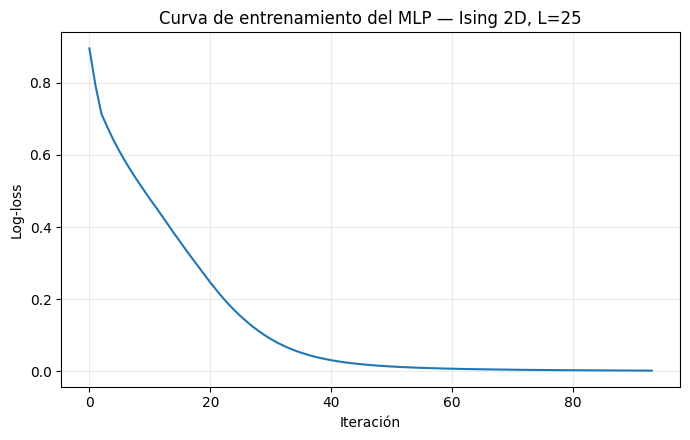

In [13]:
# ============================================================
# MLP — ISING 2D — L = 25
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

L_actual = 25

datos_L = datasets[L_actual]

X_train = datos_L["X_train"]
y_train = datos_L["y_train"]

X_val = datos_L["X_val"]
y_val = datos_L["y_val"]

X_test = datos_L["X_test"]
y_test = datos_L["y_test"]

print("=" * 70)
print(f"MLP — MODELO DE ISING 2D — L = {L_actual}")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print(f"Train clases : {np.bincount(y_train)}")
print(f"Val clases   : {np.bincount(y_val)}")
print(f"Test clases  : {np.bincount(y_test)}")


# ------------------------------------------------------------
# Crear MLP
# ------------------------------------------------------------

mlp25 = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# Entrenar
# ------------------------------------------------------------

print()
print("=" * 70)
print("ENTRENANDO...")
print("=" * 70)

mlp25.fit(X_train, y_train)


# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

pred_train25 = mlp25.predict(X_train)
pred_val25   = mlp25.predict(X_val)
pred_test25  = mlp25.predict(X_test)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

acc_train25 = accuracy_score(y_train, pred_train25)
acc_val25   = accuracy_score(y_val, pred_val25)
acc_test25  = accuracy_score(y_test, pred_test25)

print()
print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"Iteraciones realizadas : {mlp25.n_iter_}")
print(f"Log-loss final         : {mlp25.loss_:.6f}")

print()
print(f"Accuracy train : {acc_train25:.4f}")
print(f"Accuracy val   : {acc_val25:.4f}")
print(f"Accuracy test  : {acc_test25:.4f}")


# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

cm25 = confusion_matrix(y_test, pred_test25)

print()
print("=" * 70)
print("MATRIZ DE CONFUSIÓN — TEST")
print("=" * 70)

print(cm25)

print()
print("Filas    = clase real")
print("Columnas = clase predicha")
print("0 = ordenada")
print("1 = desordenada")


# ------------------------------------------------------------
# Reporte
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_test25,
        target_names=["ordenada", "desordenada"],
        digits=4
    )
)


# ------------------------------------------------------------
# Curva de pérdida
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    mlp25.loss_curve_,
    linewidth=1.5
)

plt.xlabel("Iteración")
plt.ylabel("Log-loss")

plt.title(
    "Curva de entrenamiento del MLP — Ising 2D, L=25"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ESTIMACIÓN DE Tc CON EL MLP — L = 25

BARRIDO DE TEMPERATURA CRÍTICA — L = 25
X_tc          : (6200, 25, 25)
Temperaturas  : 31
Realizaciones : 4
Rango T       : [1.600, 3.200]
Entrada MLP   : (6200, 625)

ESTIMACIÓN DE LA TEMPERATURA CRÍTICA
Tc Onsager      = 2.269185
Tc MLP (L=25)   = 2.335242
Error absoluto  = 0.066057
Error relativo  = 2.911 %


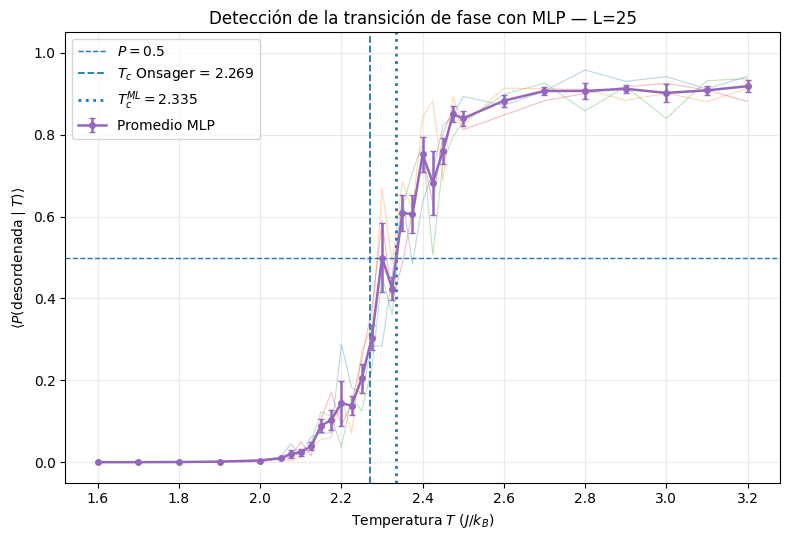


Probabilidades alrededor de la transición:


,T,prob_media,prob_std,prob_sem,m_media,m_sem
8,2.125,0.0389,0.0199,0.0100,0.8529,0.0049
9,2.150,0.0892,0.0316,0.0158,0.8251,0.0043
10,2.175,0.1037,0.0497,0.0249,0.8100,0.0119
11,2.200,0.1443,0.1091,0.0546,0.7714,0.0324
12,2.225,0.1384,0.0479,0.0240,0.7723,0.0153
13,2.250,0.2046,0.0694,0.0347,0.7410,0.0158
14,2.275,0.3043,0.0622,0.0311,0.6627,0.0177
15,2.300,0.4999,0.1687,0.0843,0.5342,0.0459
16,2.325,0.4241,0.0565,0.0283,0.5907,0.0247
17,2.350,0.6093,0.0869,0.0434,0.4463,0.0362


In [14]:
# ============================================================
# ESTIMACIÓN DE Tc CON EL MLP — L = 25
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L_actual = 25
TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Cargar dataset crítico
# ------------------------------------------------------------

ruta_tc = os.path.join(
    DATA_DIR,
    f"temperatura_critica_L{L_actual}.npz"
)

datos_tc = np.load(ruta_tc, allow_pickle=False)

X_tc = datos_tc["X"].astype(np.float32)
T_tc = datos_tc["T"].astype(np.float64)
r_tc = datos_tc["realizacion"].astype(np.int16)
m_tc = datos_tc["m"].astype(np.float64)

print("=" * 72)
print(f"BARRIDO DE TEMPERATURA CRÍTICA — L = {L_actual}")
print("=" * 72)

print(f"X_tc          : {X_tc.shape}")
print(f"Temperaturas  : {len(np.unique(T_tc))}")
print(f"Realizaciones : {len(np.unique(r_tc))}")
print(f"Rango T       : [{T_tc.min():.3f}, {T_tc.max():.3f}]")

# ------------------------------------------------------------
# 2. Aplanar configuraciones para el MLP
# ------------------------------------------------------------

X_tc_mlp = X_tc.reshape(
    len(X_tc),
    L_actual * L_actual
)

print(f"Entrada MLP   : {X_tc_mlp.shape}")

# ------------------------------------------------------------
# 3. Probabilidad de la clase desordenada
# ------------------------------------------------------------

p_desordenada = mlp25.predict_proba(X_tc_mlp)[:, 1]

# ------------------------------------------------------------
# 4. Construir DataFrame
# ------------------------------------------------------------

df_tc25 = pd.DataFrame({
    "T": T_tc,
    "realizacion": r_tc,
    "prob": p_desordenada,
    "m": m_tc
})

# ------------------------------------------------------------
# 5. Promedio por realización y temperatura
# ------------------------------------------------------------

por_realizacion25 = (
    df_tc25
    .groupby(["realizacion", "T"], as_index=False)
    .agg(
        prob=("prob", "mean"),
        m=("m", "mean")
    )
)

# ------------------------------------------------------------
# 6. Promedio configuracional entre realizaciones
# ------------------------------------------------------------

promedio_tc25 = (
    por_realizacion25
    .groupby("T", as_index=False)
    .agg(
        prob_media=("prob", "mean"),
        prob_std=("prob", "std"),
        prob_sem=("prob", "sem"),
        m_media=("m", "mean"),
        m_sem=("m", "sem")
    )
    .sort_values("T")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Buscar el cruce P = 0.5
# ------------------------------------------------------------

Tvals = promedio_tc25["T"].to_numpy()
Pvals = promedio_tc25["prob_media"].to_numpy()

cruces = []

for i in range(len(Tvals) - 1):

    p1 = Pvals[i]
    p2 = Pvals[i + 1]

    if (p1 - 0.5) * (p2 - 0.5) <= 0 and p1 != p2:

        T1 = Tvals[i]
        T2 = Tvals[i + 1]

        Tc_cruce = (
            T1
            + (0.5 - p1)
            * (T2 - T1)
            / (p2 - p1)
        )

        cruces.append(Tc_cruce)

# ------------------------------------------------------------
# 8. Seleccionar cruce más cercano a Onsager
# ------------------------------------------------------------

if len(cruces) > 0:

    Tc_ml_25 = min(
        cruces,
        key=lambda x: abs(x - TC_ONSAGER)
    )

else:

    Tc_ml_25 = np.nan

# ------------------------------------------------------------
# 9. Errores
# ------------------------------------------------------------

print()
print("=" * 72)
print("ESTIMACIÓN DE LA TEMPERATURA CRÍTICA")
print("=" * 72)

print(f"Tc Onsager      = {TC_ONSAGER:.6f}")

if np.isfinite(Tc_ml_25):

    error_abs_25 = abs(
        Tc_ml_25 - TC_ONSAGER
    )

    error_rel_25 = (
        100 * error_abs_25 / TC_ONSAGER
    )

    print(f"Tc MLP (L=25)   = {Tc_ml_25:.6f}")
    print(f"Error absoluto  = {error_abs_25:.6f}")
    print(f"Error relativo  = {error_rel_25:.3f} %")

else:

    print("No se encontró cruce con P = 0.5.")

# ------------------------------------------------------------
# 10. Gráfica
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Realizaciones individuales
for r, sub in por_realizacion25.groupby("realizacion"):

    sub = sub.sort_values("T")

    ax.plot(
        sub["T"],
        sub["prob"],
        "-",
        lw=0.8,
        alpha=0.30
    )

# Promedio + error
ax.errorbar(
    promedio_tc25["T"],
    promedio_tc25["prob_media"],
    yerr=promedio_tc25["prob_sem"],
    fmt="o-",
    lw=1.8,
    ms=4,
    capsize=2,
    label="Promedio MLP"
)

# P = 0.5
ax.axhline(
    0.5,
    ls="--",
    lw=1,
    label=r"$P=0.5$"
)

# Tc exacta
ax.axvline(
    TC_ONSAGER,
    ls="--",
    lw=1.3,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.3f}"
)

# Tc obtenida por ML
if np.isfinite(Tc_ml_25):

    ax.axvline(
        Tc_ml_25,
        ls=":",
        lw=2,
        label=fr"$T_c^{{ML}}={Tc_ml_25:.3f}$"
    )

ax.set_xlabel(
    r"Temperatura $T$ ($J/k_B$)"
)

ax.set_ylabel(
    r"$\langle P(\mathrm{desordenada}\mid T)\rangle$"
)

ax.set_title(
    "Detección de la transición de fase con MLP — L=25"
)

ax.set_ylim(-0.05, 1.05)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Mostrar región crítica
# ------------------------------------------------------------

zona_critica25 = promedio_tc25[
    (promedio_tc25["T"] >= 2.10)
    &
    (promedio_tc25["T"] <= 2.45)
]

print()
print("Probabilidades alrededor de la transición:")

display(
    zona_critica25.round(4)
)

datos_tc.close()

# MLP — ISING 2D — L = 30

MLP — MODELO DE ISING 2D — L = 30
X_train : (800, 900)
X_val   : (400, 900)
X_test  : (400, 900)

Train clases : [400 400]
Val clases   : [200 200]
Test clases  : [200 200]

ENTRENANDO...

RESULTADOS
Iteraciones realizadas : 762
Log-loss final         : 0.044722

Accuracy train : 1.0000
Accuracy val   : 0.9925
Accuracy test  : 0.9800

MATRIZ DE CONFUSIÓN — TEST
[[200   0]
 [  8 192]]

Filas    = clase real
Columnas = clase predicha
0 = ordenada
1 = desordenada

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

    ordenada     0.9615    1.0000    0.9804       200
 desordenada     1.0000    0.9600    0.9796       200

    accuracy                         0.9800       400
   macro avg     0.9808    0.9800    0.9800       400
weighted avg     0.9808    0.9800    0.9800       400



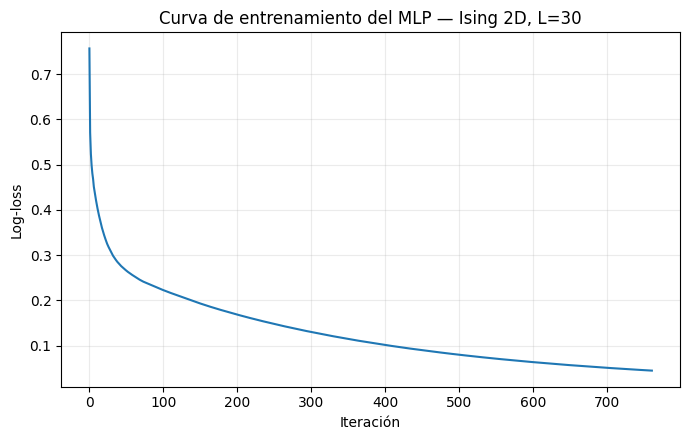

In [15]:
# ============================================================
# MLP — ISING 2D — L = 30
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

L_actual = 30

datos_L = datasets[L_actual]

X_train = datos_L["X_train"]
y_train = datos_L["y_train"]

X_val = datos_L["X_val"]
y_val = datos_L["y_val"]

X_test = datos_L["X_test"]
y_test = datos_L["y_test"]

print("=" * 70)
print(f"MLP — MODELO DE ISING 2D — L = {L_actual}")
print("=" * 70)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print(f"Train clases : {np.bincount(y_train)}")
print(f"Val clases   : {np.bincount(y_val)}")
print(f"Test clases  : {np.bincount(y_test)}")


# ------------------------------------------------------------
# Crear MLP
# ------------------------------------------------------------

mlp30 = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    verbose=False
)


# ------------------------------------------------------------
# Entrenar
# ------------------------------------------------------------

print()
print("=" * 70)
print("ENTRENANDO...")
print("=" * 70)

mlp30.fit(X_train, y_train)


# ------------------------------------------------------------
# Predicciones
# ------------------------------------------------------------

pred_train30 = mlp30.predict(X_train)
pred_val30   = mlp30.predict(X_val)
pred_test30  = mlp30.predict(X_test)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

acc_train30 = accuracy_score(y_train, pred_train30)
acc_val30   = accuracy_score(y_val, pred_val30)
acc_test30  = accuracy_score(y_test, pred_test30)

print()
print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"Iteraciones realizadas : {mlp30.n_iter_}")
print(f"Log-loss final         : {mlp30.loss_:.6f}")

print()
print(f"Accuracy train : {acc_train30:.4f}")
print(f"Accuracy val   : {acc_val30:.4f}")
print(f"Accuracy test  : {acc_test30:.4f}")


# ------------------------------------------------------------
# Matriz de confusión
# ------------------------------------------------------------

cm30 = confusion_matrix(y_test, pred_test30)

print()
print("=" * 70)
print("MATRIZ DE CONFUSIÓN — TEST")
print("=" * 70)

print(cm30)

print()
print("Filas    = clase real")
print("Columnas = clase predicha")
print("0 = ordenada")
print("1 = desordenada")


# ------------------------------------------------------------
# Reporte de clasificación
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 70)

print(
    classification_report(
        y_test,
        pred_test30,
        target_names=["ordenada", "desordenada"],
        digits=4
    )
)


# ------------------------------------------------------------
# Curva de pérdida
# ------------------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    mlp30.loss_curve_,
    linewidth=1.5
)

plt.xlabel("Iteración")
plt.ylabel("Log-loss")

plt.title(
    "Curva de entrenamiento del MLP — Ising 2D, L=30"
)

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ESTIMACIÓN DE Tc CON EL MLP — L = 30

BARRIDO DE TEMPERATURA CRÍTICA — L = 30
X_tc          : (6200, 30, 30)
Temperaturas  : 31
Realizaciones : 4
Rango T       : [1.600, 3.200]
Entrada MLP   : (6200, 900)

ESTIMACIÓN DE LA TEMPERATURA CRÍTICA
Tc Onsager      = 2.269185
Tc MLP (L=30)   = 2.287888
Error absoluto  = 0.018702
Error relativo  = 0.824 %


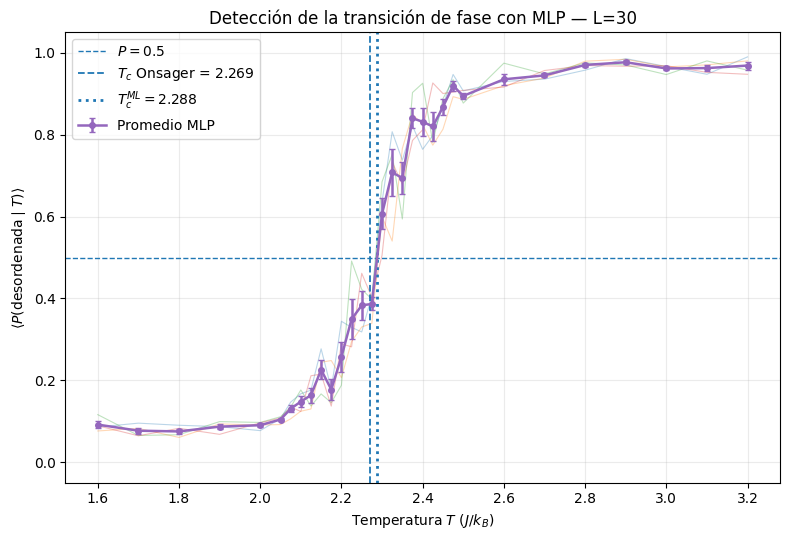


Probabilidades alrededor de la transición:


,T,prob_media,prob_std,prob_sem,m_media,m_sem
8,2.125,0.1637,0.0375,0.0188,0.8617,0.0035
9,2.150,0.2259,0.0467,0.0234,0.8305,0.0085
10,2.175,0.1776,0.0506,0.0253,0.8209,0.0050
11,2.200,0.2570,0.0729,0.0365,0.7702,0.0225
12,2.225,0.3494,0.0967,0.0483,0.7515,0.0106
13,2.250,0.3831,0.0699,0.0350,0.7024,0.0205
14,2.275,0.3867,0.0319,0.0160,0.6958,0.0138
15,2.300,0.6065,0.0759,0.0380,0.5193,0.0451
16,2.325,0.7080,0.1162,0.0581,0.4589,0.0419
17,2.350,0.6942,0.0760,0.0380,0.4161,0.0527


In [16]:
# ============================================================
# ESTIMACIÓN DE Tc CON EL MLP — L = 30
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

L_actual = 30
TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Cargar dataset crítico
# ------------------------------------------------------------

ruta_tc = os.path.join(
    DATA_DIR,
    f"temperatura_critica_L{L_actual}.npz"
)

datos_tc = np.load(ruta_tc, allow_pickle=False)

X_tc = datos_tc["X"].astype(np.float32)
T_tc = datos_tc["T"].astype(np.float64)
r_tc = datos_tc["realizacion"].astype(np.int16)
m_tc = datos_tc["m"].astype(np.float64)

print("=" * 72)
print(f"BARRIDO DE TEMPERATURA CRÍTICA — L = {L_actual}")
print("=" * 72)

print(f"X_tc          : {X_tc.shape}")
print(f"Temperaturas  : {len(np.unique(T_tc))}")
print(f"Realizaciones : {len(np.unique(r_tc))}")
print(f"Rango T       : [{T_tc.min():.3f}, {T_tc.max():.3f}]")

# ------------------------------------------------------------
# 2. Preparar entrada para MLP
# ------------------------------------------------------------

X_tc_mlp = X_tc.reshape(
    len(X_tc),
    L_actual * L_actual
)

print(f"Entrada MLP   : {X_tc_mlp.shape}")

# ------------------------------------------------------------
# 3. Probabilidad P(desordenada)
# ------------------------------------------------------------

p_desordenada = mlp30.predict_proba(X_tc_mlp)[:, 1]

# ------------------------------------------------------------
# 4. DataFrame
# ------------------------------------------------------------

df_tc30 = pd.DataFrame({
    "T": T_tc,
    "realizacion": r_tc,
    "prob": p_desordenada,
    "m": m_tc
})

# ------------------------------------------------------------
# 5. Promedio dentro de cada realización
# ------------------------------------------------------------

por_realizacion30 = (
    df_tc30
    .groupby(["realizacion", "T"], as_index=False)
    .agg(
        prob=("prob", "mean"),
        m=("m", "mean")
    )
)

# ------------------------------------------------------------
# 6. Promedio entre realizaciones
# ------------------------------------------------------------

promedio_tc30 = (
    por_realizacion30
    .groupby("T", as_index=False)
    .agg(
        prob_media=("prob", "mean"),
        prob_std=("prob", "std"),
        prob_sem=("prob", "sem"),
        m_media=("m", "mean"),
        m_sem=("m", "sem")
    )
    .sort_values("T")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. Buscar cruces con P = 0.5
# ------------------------------------------------------------

Tvals = promedio_tc30["T"].to_numpy()
Pvals = promedio_tc30["prob_media"].to_numpy()

cruces = []

for i in range(len(Tvals) - 1):

    p1 = Pvals[i]
    p2 = Pvals[i + 1]

    if (p1 - 0.5) * (p2 - 0.5) <= 0 and p1 != p2:

        T1 = Tvals[i]
        T2 = Tvals[i + 1]

        Tc_cruce = (
            T1
            + (0.5 - p1)
            * (T2 - T1)
            / (p2 - p1)
        )

        cruces.append(Tc_cruce)

# ------------------------------------------------------------
# 8. Seleccionar cruce más cercano a Onsager
# ------------------------------------------------------------

if len(cruces) > 0:

    Tc_ml_30 = min(
        cruces,
        key=lambda x: abs(x - TC_ONSAGER)
    )

else:

    Tc_ml_30 = np.nan

# ------------------------------------------------------------
# 9. Errores
# ------------------------------------------------------------

print()
print("=" * 72)
print("ESTIMACIÓN DE LA TEMPERATURA CRÍTICA")
print("=" * 72)

print(f"Tc Onsager      = {TC_ONSAGER:.6f}")

if np.isfinite(Tc_ml_30):

    error_abs_30 = abs(Tc_ml_30 - TC_ONSAGER)
    error_rel_30 = 100 * error_abs_30 / TC_ONSAGER

    print(f"Tc MLP (L=30)   = {Tc_ml_30:.6f}")
    print(f"Error absoluto  = {error_abs_30:.6f}")
    print(f"Error relativo  = {error_rel_30:.3f} %")

else:

    print("No se encontró cruce con P = 0.5.")

# ------------------------------------------------------------
# 10. Gráfica
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

# Realizaciones individuales
for r, sub in por_realizacion30.groupby("realizacion"):

    sub = sub.sort_values("T")

    ax.plot(
        sub["T"],
        sub["prob"],
        "-",
        lw=0.8,
        alpha=0.30
    )

# Promedio con barras de error
ax.errorbar(
    promedio_tc30["T"],
    promedio_tc30["prob_media"],
    yerr=promedio_tc30["prob_sem"],
    fmt="o-",
    lw=1.8,
    ms=4,
    capsize=2,
    label="Promedio MLP"
)

# P = 0.5
ax.axhline(
    0.5,
    ls="--",
    lw=1,
    label=r"$P=0.5$"
)

# Tc exacta de Onsager
ax.axvline(
    TC_ONSAGER,
    ls="--",
    lw=1.3,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.3f}"
)

# Tc estimada por ML
if np.isfinite(Tc_ml_30):

    ax.axvline(
        Tc_ml_30,
        ls=":",
        lw=2,
        label=fr"$T_c^{{ML}}={Tc_ml_30:.3f}$"
    )

ax.set_xlabel(
    r"Temperatura $T$ ($J/k_B$)"
)

ax.set_ylabel(
    r"$\langle P(\mathrm{desordenada}\mid T)\rangle$"
)

ax.set_title(
    "Detección de la transición de fase con MLP — L=30"
)

ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Tabla de la región crítica
# ------------------------------------------------------------

zona_critica30 = promedio_tc30[
    (promedio_tc30["T"] >= 2.10)
    &
    (promedio_tc30["T"] <= 2.45)
]

print()
print("Probabilidades alrededor de la transición:")

display(zona_critica30.round(4))

datos_tc.close()

# ANÁLISIS CONJUNTO DE Tc — L = 10, 15, 20, 25, 30


ANALIZANDO L = 10
realización 0: Tc_ML = 2.360083
realización 1: Tc_ML = 2.379057
realización 2: Tc_ML = 2.321564
realización 3: Tc_ML = 2.342261
------------------------------------------------------------------------
Tc curva promedio = 2.366980
Tc media realizaciones = 2.350741
desviación estándar = 0.024578
error estándar = 0.012289

ANALIZANDO L = 15
realización 0: Tc_ML = 2.285480
realización 1: Tc_ML = 2.357379
realización 2: Tc_ML = 2.355463
realización 3: Tc_ML = 2.357582
------------------------------------------------------------------------
Tc curva promedio = 2.355936
Tc media realizaciones = 2.338976
desviación estándar = 0.035677
error estándar = 0.017838

ANALIZANDO L = 20
realización 0: Tc_ML = 2.339160
realización 1: Tc_ML = 2.342846
realización 2: Tc_ML = 2.355324
realización 3: Tc_ML = 2.366278
------------------------------------------------------------------------
Tc curva promedio = 2.352578
Tc media realizaciones = 2.350902
desviación estándar = 0.012366
error 

,L,1/L,Tc_curva,Tc_media_R,Tc_std_R,Tc_sem_R,error_abs,error_rel_%,R_validas
0,10,0.100000,2.366980,2.350741,0.024578,0.012289,0.097795,4.309692,4
1,15,0.066667,2.355936,2.338976,0.035677,0.017838,0.086750,3.822969,4
2,20,0.050000,2.352578,2.350902,0.012366,0.006183,0.083392,3.674992,4
3,25,0.040000,2.335242,2.311549,0.026784,0.013392,0.066057,2.911052,4
4,30,0.033333,2.287888,2.289541,0.006728,0.003364,0.018702,0.824187,4



Tc POR REALIZACIÓN


,L,realizacion,Tc_ML
0,10,0,2.360083
1,10,1,2.379057
2,10,2,2.321564
3,10,3,2.342261
4,15,0,2.285480
5,15,1,2.357379
6,15,2,2.355463
7,15,3,2.357582
8,20,0,2.339160
9,20,1,2.342846


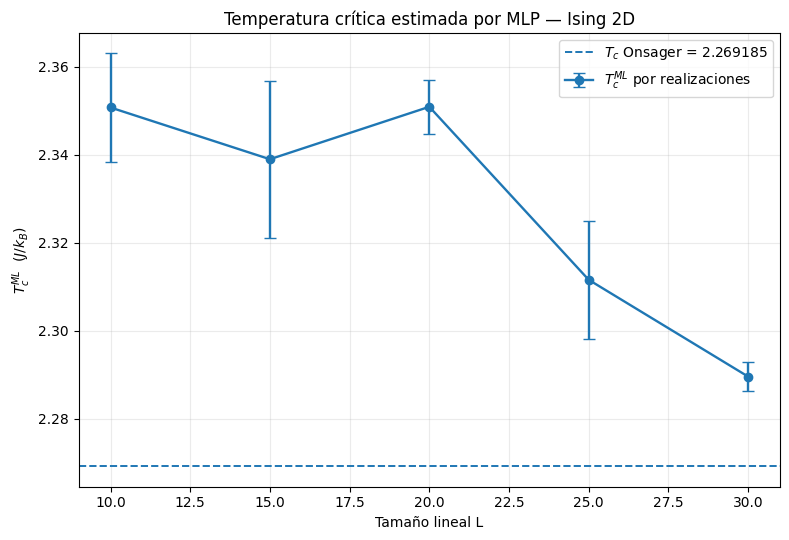

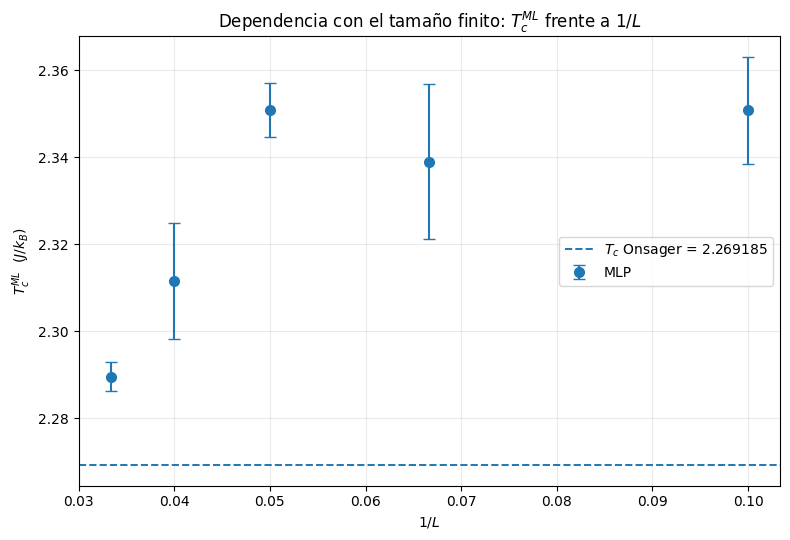

In [17]:
# ============================================================
# ANÁLISIS CONJUNTO DE Tc — L = 10, 15, 20, 25, 30
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------------------
# 1. Recuperar el modelo de L=10
# ------------------------------------------------------------

if "mlp10" in globals():
    modelo10 = mlp10
elif "mlp" in globals():
    modelo10 = mlp
else:
    raise NameError(
        "No encuentro el MLP de L=10. "
        "Debe llamarse 'mlp10' o 'mlp'."
    )

modelos = {
    10: modelo10,
    15: mlp15,
    20: mlp20,
    25: mlp25,
    30: mlp30
}

# ------------------------------------------------------------
# 2. Función para encontrar el PRIMER CRUCE ASCENDENTE P=0.5
#
# Importante:
# NO usamos Tc de Onsager para escoger el cruce.
# ------------------------------------------------------------

def cruce_ascendente(T, P, nivel=0.5):

    T = np.asarray(T, dtype=float)
    P = np.asarray(P, dtype=float)

    orden = np.argsort(T)
    T = T[orden]
    P = P[orden]

    for i in range(len(T) - 1):

        if P[i] < nivel and P[i + 1] >= nivel:

            if P[i + 1] == P[i]:
                return 0.5 * (T[i] + T[i + 1])

            Tc = (
                T[i]
                + (nivel - P[i])
                * (T[i + 1] - T[i])
                / (P[i + 1] - P[i])
            )

            return Tc

    return np.nan


# ------------------------------------------------------------
# 3. Analizar cada tamaño
# ------------------------------------------------------------

resultados = []
resultados_realizaciones = []

for L, modelo in modelos.items():

    print()
    print("=" * 72)
    print(f"ANALIZANDO L = {L}")
    print("=" * 72)

    ruta = os.path.join(
        DATA_DIR,
        f"temperatura_critica_L{L}.npz"
    )

    datos = np.load(ruta, allow_pickle=False)

    X = datos["X"].astype(np.float32)
    T = datos["T"].astype(float)
    R = datos["realizacion"].astype(int)

    # Aplanar configuraciones
    X_mlp = X.reshape(len(X), L * L)

    # Probabilidad de fase desordenada
    prob = modelo.predict_proba(X_mlp)[:, 1]

    df = pd.DataFrame({
        "T": T,
        "realizacion": R,
        "prob": prob
    })

    # --------------------------------------------------------
    # Promedio de las configuraciones de cada realización
    # --------------------------------------------------------

    por_r = (
        df.groupby(
            ["realizacion", "T"],
            as_index=False
        )
        .agg(prob=("prob", "mean"))
    )

    # --------------------------------------------------------
    # Tc independiente para cada realización
    # --------------------------------------------------------

    Tc_realizaciones = []

    for r, sub in por_r.groupby("realizacion"):

        sub = sub.sort_values("T")

        Tc_r = cruce_ascendente(
            sub["T"].to_numpy(),
            sub["prob"].to_numpy()
        )

        Tc_realizaciones.append(Tc_r)

        resultados_realizaciones.append({
            "L": L,
            "realizacion": r,
            "Tc_ML": Tc_r
        })

        print(
            f"realización {r}: "
            f"Tc_ML = {Tc_r:.6f}"
        )

    Tc_realizaciones = np.asarray(
        Tc_realizaciones,
        dtype=float
    )

    validos = Tc_realizaciones[
        np.isfinite(Tc_realizaciones)
    ]

    # --------------------------------------------------------
    # Estadística entre realizaciones
    # --------------------------------------------------------

    Tc_media = np.mean(validos)

    if len(validos) > 1:

        Tc_std = np.std(
            validos,
            ddof=1
        )

        Tc_sem = (
            Tc_std /
            np.sqrt(len(validos))
        )

    else:

        Tc_std = np.nan
        Tc_sem = np.nan

    # --------------------------------------------------------
    # También calculamos el cruce de la curva promedio
    # --------------------------------------------------------

    promedio = (
        por_r.groupby("T", as_index=False)
        .agg(prob_media=("prob", "mean"))
        .sort_values("T")
    )

    Tc_curva_promedio = cruce_ascendente(
        promedio["T"].to_numpy(),
        promedio["prob_media"].to_numpy()
    )

    # --------------------------------------------------------
    # Errores respecto a Onsager
    # --------------------------------------------------------

    error_abs = abs(
        Tc_curva_promedio - TC_ONSAGER
    )

    error_rel = (
        100 * error_abs / TC_ONSAGER
    )

    resultados.append({
        "L": L,
        "1/L": 1.0 / L,
        "Tc_curva": Tc_curva_promedio,
        "Tc_media_R": Tc_media,
        "Tc_std_R": Tc_std,
        "Tc_sem_R": Tc_sem,
        "error_abs": error_abs,
        "error_rel_%": error_rel,
        "R_validas": len(validos)
    })

    print("-" * 72)

    print(
        f"Tc curva promedio = "
        f"{Tc_curva_promedio:.6f}"
    )

    print(
        f"Tc media realizaciones = "
        f"{Tc_media:.6f}"
    )

    print(
        f"desviación estándar = "
        f"{Tc_std:.6f}"
    )

    print(
        f"error estándar = "
        f"{Tc_sem:.6f}"
    )

    datos.close()


# ------------------------------------------------------------
# 4. DataFrames finales
# ------------------------------------------------------------

tabla_tc = pd.DataFrame(resultados)

tabla_realizaciones = pd.DataFrame(
    resultados_realizaciones
)

print()
print("=" * 80)
print("RESULTADOS FINALES")
print("=" * 80)

display(
    tabla_tc.round(6)
)

print()
print("=" * 80)
print("Tc POR REALIZACIÓN")
print("=" * 80)

display(
    tabla_realizaciones.round(6)
)


# ------------------------------------------------------------
# 5. Gráfica Tc frente a L
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.errorbar(
    tabla_tc["L"],
    tabla_tc["Tc_media_R"],
    yerr=tabla_tc["Tc_sem_R"],
    fmt="o-",
    capsize=4,
    lw=1.7,
    ms=6,
    label=r"$T_c^{ML}$ por realizaciones"
)

ax.axhline(
    TC_ONSAGER,
    ls="--",
    lw=1.4,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.6f}"
)

ax.set_xlabel("Tamaño lineal L")
ax.set_ylabel(r"$T_c^{ML}$  ($J/k_B$)")

ax.set_title(
    "Temperatura crítica estimada por MLP — Ising 2D"
)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Gráfica Tc frente a 1/L
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.errorbar(
    tabla_tc["1/L"],
    tabla_tc["Tc_media_R"],
    yerr=tabla_tc["Tc_sem_R"],
    fmt="o",
    capsize=4,
    ms=7,
    label="MLP"
)

ax.axhline(
    TC_ONSAGER,
    ls="--",
    lw=1.4,
    label=fr"$T_c$ Onsager = {TC_ONSAGER:.6f}"
)

ax.set_xlabel(r"$1/L$")
ax.set_ylabel(r"$T_c^{ML}$  ($J/k_B$)")

ax.set_title(
    r"Dependencia con el tamaño finito: $T_c^{ML}$ frente a $1/L$"
)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

ESCALAMIENTO DE TAMAÑO FINITO

Modelo:
Tc(L) = Tc(infinito) + a/L

------------------------------------------------------------------------
AJUSTE NO PONDERADO
------------------------------------------------------------------------
Tc(infinito) = 2.28514557
a            = 0.74476346
R²           = 0.540248

Tc Onsager   = 2.26918531
Error abs.   = 0.01596025
Error rel.   = 0.7033 %

------------------------------------------------------------------------
AJUSTE PONDERADO POR INCERTIDUMBRE
------------------------------------------------------------------------
Tc(infinito) = 2.25408593 ± 0.02809438
a            = 1.28881925 ± 0.63690016

Tc Onsager   = 2.26918531
Error abs.   = 0.01509939
Error rel.   = 0.6654 %

TABLA DEL ESCALAMIENTO


,L,1/L,Tc_ML,Tc_SEM,Tc_ajuste_no_pond,Tc_ajuste_pond,residuo_no_pond,residuo_pond
0,10,0.100000,2.350741,0.012289,2.359622,2.382968,-0.008880,-0.032226
1,15,0.066667,2.338976,0.017838,2.334796,2.340007,0.004179,-0.001031
2,20,0.050000,2.350902,0.006183,2.322384,2.318527,0.028518,0.032375
3,25,0.040000,2.311549,0.013392,2.314936,2.305639,-0.003387,0.005910
4,30,0.033333,2.289541,0.003364,2.309971,2.297047,-0.020430,-0.007505


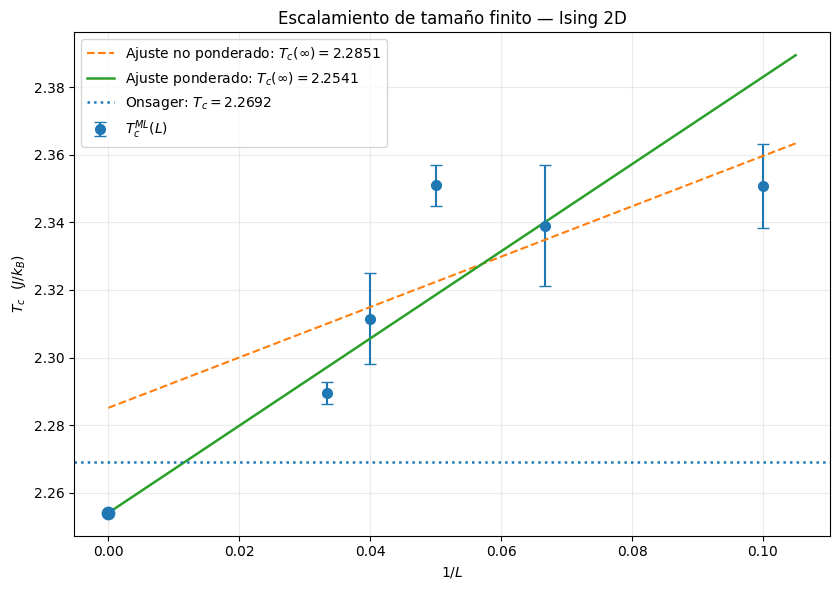

In [18]:
# ================================================================
# ESCALAMIENTO DE TAMAÑO FINITO
# Tc(L) = Tc(infinito) + a/L
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# ------------------------------------------------
# 1. Datos obtenidos anteriormente
# ------------------------------------------------

L_vals = tabla_tc["L"].to_numpy(dtype=float)
Tc_vals = tabla_tc["Tc_media_R"].to_numpy(dtype=float)
Tc_err  = tabla_tc["Tc_sem_R"].to_numpy(dtype=float)

x = 1.0 / L_vals


# ------------------------------------------------
# 2. Ajuste lineal NO ponderado
#
# Tc(L) = Tc_inf + a/L
# ------------------------------------------------

coef = np.polyfit(x, Tc_vals, 1)

a_np = coef[0]
Tc_inf_np = coef[1]

Tc_pred_np = Tc_inf_np + a_np * x

residuos_np = Tc_vals - Tc_pred_np

ss_res = np.sum(residuos_np**2)
ss_tot = np.sum((Tc_vals - Tc_vals.mean())**2)

R2_np = 1.0 - ss_res / ss_tot


# ------------------------------------------------
# 3. Ajuste lineal ponderado
#
# pesos = 1 / sigma^2
# ------------------------------------------------

pesos_polyfit = 1.0 / Tc_err

coef_w, cov_w = np.polyfit(
    x,
    Tc_vals,
    1,
    w=pesos_polyfit,
    cov=True
)

a_w = coef_w[0]
Tc_inf_w = coef_w[1]

a_w_err = np.sqrt(cov_w[0, 0])
Tc_inf_w_err = np.sqrt(cov_w[1, 1])

Tc_pred_w = Tc_inf_w + a_w * x


# ------------------------------------------------
# 4. Comparación con Onsager
# ------------------------------------------------

error_abs_np = abs(Tc_inf_np - TC_ONSAGER)
error_rel_np = 100 * error_abs_np / TC_ONSAGER

error_abs_w = abs(Tc_inf_w - TC_ONSAGER)
error_rel_w = 100 * error_abs_w / TC_ONSAGER


# ------------------------------------------------
# 5. Imprimir resultados
# ------------------------------------------------

print("=" * 72)
print("ESCALAMIENTO DE TAMAÑO FINITO")
print("=" * 72)

print("\nModelo:")
print("Tc(L) = Tc(infinito) + a/L")


print("\n" + "-" * 72)
print("AJUSTE NO PONDERADO")
print("-" * 72)

print(f"Tc(infinito) = {Tc_inf_np:.8f}")
print(f"a            = {a_np:.8f}")
print(f"R²           = {R2_np:.6f}")

print(f"\nTc Onsager   = {TC_ONSAGER:.8f}")
print(f"Error abs.   = {error_abs_np:.8f}")
print(f"Error rel.   = {error_rel_np:.4f} %")


print("\n" + "-" * 72)
print("AJUSTE PONDERADO POR INCERTIDUMBRE")
print("-" * 72)

print(
    f"Tc(infinito) = {Tc_inf_w:.8f} "
    f"± {Tc_inf_w_err:.8f}"
)

print(
    f"a            = {a_w:.8f} "
    f"± {a_w_err:.8f}"
)

print(f"\nTc Onsager   = {TC_ONSAGER:.8f}")
print(f"Error abs.   = {error_abs_w:.8f}")
print(f"Error rel.   = {error_rel_w:.4f} %")


# ------------------------------------------------
# 6. Tabla
# ------------------------------------------------

tabla_escalamiento = pd.DataFrame({

    "L": L_vals.astype(int),

    "1/L": x,

    "Tc_ML": Tc_vals,

    "Tc_SEM": Tc_err,

    "Tc_ajuste_no_pond": Tc_pred_np,

    "Tc_ajuste_pond": Tc_pred_w,

    "residuo_no_pond":
        Tc_vals - Tc_pred_np,

    "residuo_pond":
        Tc_vals - Tc_pred_w
})

print("\n" + "=" * 72)
print("TABLA DEL ESCALAMIENTO")
print("=" * 72)

display(tabla_escalamiento.round(6))


# ------------------------------------------------
# 7. Gráfica
# ------------------------------------------------

x_fit = np.linspace(0, x.max() * 1.05, 300)

y_fit_np = Tc_inf_np + a_np * x_fit
y_fit_w  = Tc_inf_w  + a_w  * x_fit


fig, ax = plt.subplots(figsize=(8.5, 6))


# Datos MLP
ax.errorbar(
    x,
    Tc_vals,
    yerr=Tc_err,
    fmt="o",
    capsize=4,
    ms=7,
    label=r"$T_c^{ML}(L)$"
)


# Ajuste no ponderado
ax.plot(
    x_fit,
    y_fit_np,
    "--",
    lw=1.5,
    label=fr"Ajuste no ponderado: $T_c(\infty)={Tc_inf_np:.4f}$"
)


# Ajuste ponderado
ax.plot(
    x_fit,
    y_fit_w,
    "-",
    lw=1.8,
    label=fr"Ajuste ponderado: $T_c(\infty)={Tc_inf_w:.4f}$"
)


# Onsager
ax.axhline(
    TC_ONSAGER,
    ls=":",
    lw=1.8,
    label=fr"Onsager: $T_c={TC_ONSAGER:.4f}$"
)


# Punto extrapolado
ax.scatter(
    [0],
    [Tc_inf_w],
    s=80,
    zorder=5
)


ax.set_xlabel(r"$1/L$")
ax.set_ylabel(r"$T_c$  ($J/k_B$)")

ax.set_title(
    "Escalamiento de tamaño finito — Ising 2D"
)

ax.grid(alpha=0.25)

ax.legend()

fig.tight_layout()

plt.show()

ESTABILIDAD DEL ESCALAMIENTO DE TAMAÑO FINITO


,L_min,N_puntos,tipo,Tc_inf,a,R2,error_abs_Onsager,error_rel_%,Tc_inf_err,a_err,chi2_red
0,10,5,no ponderado,2.285146,0.744763,0.540248,0.015960,0.703347,NaN,NaN,NaN
1,10,5,ponderado,2.254086,1.288819,NaN,0.015099,0.665410,0.028094,0.636900,13.156375
2,15,4,no ponderado,2.252245,1.484151,0.608089,0.016941,0.746547,NaN,NaN,NaN
3,15,4,ponderado,2.195201,2.883041,NaN,0.073984,3.260392,0.031871,0.819365,5.569432
4,20,3,no ponderado,2.165151,3.701659,0.997810,0.104034,4.584640,NaN,NaN,NaN
5,20,3,ponderado,2.166957,3.674811,NaN,0.102229,4.505085,0.002937,0.077504,0.033938



Tc(infinito) OBTENIDO AL CAMBIAR EL TAMAÑO MÍNIMO
L >= 10 | no ponderado | Tc(inf) = 2.285146
L >= 10 | ponderado    | Tc(inf) = 2.254086 ± 0.028094
L >= 15 | no ponderado | Tc(inf) = 2.252245
L >= 15 | ponderado    | Tc(inf) = 2.195201 ± 0.031871
L >= 20 | no ponderado | Tc(inf) = 2.165151
L >= 20 | ponderado    | Tc(inf) = 2.166957 ± 0.002937

Referencia de Onsager = 2.269185


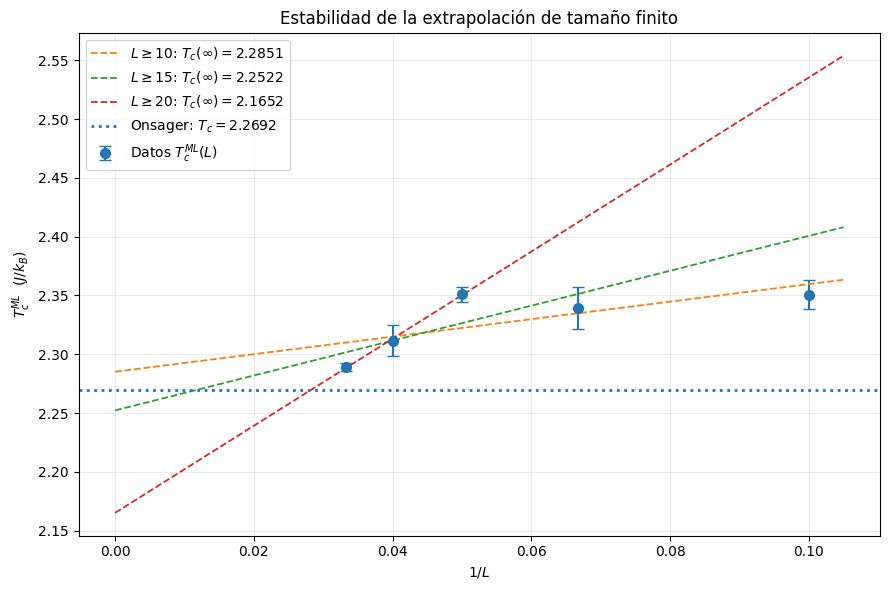

In [19]:
# ================================================================
# DIAGNÓSTICO DE ESTABILIDAD DEL ESCALAMIENTO
#
# Ajustamos:
#     Tc(L) = Tc(infinito) + a/L
#
# usando progresivamente:
# L >= 10
# L >= 15
# L >= 20
#
# No utilizamos Tc de Onsager para hacer los ajustes.
# Onsager aparece solamente DESPUÉS como referencia.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

L_all = tabla_tc["L"].to_numpy(dtype=float)
Tc_all = tabla_tc["Tc_media_R"].to_numpy(dtype=float)
err_all = tabla_tc["Tc_sem_R"].to_numpy(dtype=float)

resultados_fit = []

# ------------------------------------------------
# Realizamos varios ajustes
# ------------------------------------------------

for Lmin in [10, 15, 20]:

    mask = L_all >= Lmin

    L = L_all[mask]
    Tc = Tc_all[mask]
    err = err_all[mask]

    x = 1.0 / L

    # ============================================
    # AJUSTE NO PONDERADO
    # ============================================

    coef = np.polyfit(x, Tc, 1)

    a = coef[0]
    Tc_inf = coef[1]

    pred = Tc_inf + a*x

    residuos = Tc - pred

    ss_res = np.sum(residuos**2)
    ss_tot = np.sum((Tc - Tc.mean())**2)

    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    resultados_fit.append({
        "L_min": Lmin,
        "N_puntos": len(L),
        "tipo": "no ponderado",
        "Tc_inf": Tc_inf,
        "a": a,
        "R2": R2,
        "error_abs_Onsager": abs(Tc_inf - TC_ONSAGER),
        "error_rel_%": 100*abs(Tc_inf-TC_ONSAGER)/TC_ONSAGER
    })

    # ============================================
    # AJUSTE PONDERADO
    # ============================================

    coef_w, cov_w = np.polyfit(
        x,
        Tc,
        1,
        w=1.0/err,
        cov=True
    )

    a_w = coef_w[0]
    Tc_inf_w = coef_w[1]

    a_err = np.sqrt(cov_w[0,0])
    Tc_inf_err = np.sqrt(cov_w[1,1])

    pred_w = Tc_inf_w + a_w*x

    residuos_w = Tc - pred_w

    chi2 = np.sum((residuos_w/err)**2)

    dof = len(Tc) - 2

    chi2_red = chi2/dof if dof > 0 else np.nan

    resultados_fit.append({
        "L_min": Lmin,
        "N_puntos": len(L),
        "tipo": "ponderado",
        "Tc_inf": Tc_inf_w,
        "Tc_inf_err": Tc_inf_err,
        "a": a_w,
        "a_err": a_err,
        "chi2_red": chi2_red,
        "error_abs_Onsager": abs(Tc_inf_w - TC_ONSAGER),
        "error_rel_%": 100*abs(Tc_inf_w-TC_ONSAGER)/TC_ONSAGER
    })


# ------------------------------------------------
# Tabla
# ------------------------------------------------

tabla_estabilidad = pd.DataFrame(resultados_fit)

print("="*90)
print("ESTABILIDAD DEL ESCALAMIENTO DE TAMAÑO FINITO")
print("="*90)

display(tabla_estabilidad.round(6))


# ------------------------------------------------
# Mostrar solamente extrapolaciones
# ------------------------------------------------

print()
print("="*90)
print("Tc(infinito) OBTENIDO AL CAMBIAR EL TAMAÑO MÍNIMO")
print("="*90)

for _, fila in tabla_estabilidad.iterrows():

    if fila["tipo"] == "ponderado":

        print(
            f"L >= {int(fila['L_min']):2d} | "
            f"{fila['tipo']:12s} | "
            f"Tc(inf) = {fila['Tc_inf']:.6f} "
            f"± {fila['Tc_inf_err']:.6f}"
        )

    else:

        print(
            f"L >= {int(fila['L_min']):2d} | "
            f"{fila['tipo']:12s} | "
            f"Tc(inf) = {fila['Tc_inf']:.6f}"
        )

print()
print(f"Referencia de Onsager = {TC_ONSAGER:.6f}")


# ================================================================
# GRÁFICA
# ================================================================

fig, ax = plt.subplots(figsize=(9,6))

# Datos originales
ax.errorbar(
    1/L_all,
    Tc_all,
    yerr=err_all,
    fmt='o',
    capsize=4,
    ms=7,
    label=r'Datos $T_c^{ML}(L)$'
)

# Valores de x para extrapolar hasta L infinito
xfit = np.linspace(0, 1/L_all.min()*1.05, 300)

# ------------------------------------------------
# Rectas NO ponderadas para distintos Lmin
# ------------------------------------------------

for Lmin in [10,15,20]:

    fila = tabla_estabilidad[
        (tabla_estabilidad["L_min"] == Lmin) &
        (tabla_estabilidad["tipo"] == "no ponderado")
    ].iloc[0]

    yfit = fila["Tc_inf"] + fila["a"]*xfit

    ax.plot(
        xfit,
        yfit,
        "--",
        lw=1.3,
        label=fr"$L\geq {Lmin}$: "
              fr"$T_c(\infty)={fila['Tc_inf']:.4f}$"
    )


# Onsager
ax.axhline(
    TC_ONSAGER,
    linestyle=":",
    linewidth=2,
    label=fr"Onsager: $T_c={TC_ONSAGER:.4f}$"
)


ax.set_xlabel(r"$1/L$")
ax.set_ylabel(r"$T_c^{ML}$  ($J/k_B$)")

ax.set_title(
    "Estabilidad de la extrapolación de tamaño finito"
)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

RESULTADOS FINALES — RETO ISING 2D + MLP


,L,N=L^2,Tc_ML,Tc_Onsager,Error_absoluto,Error_relativo_%
0,10,100,2.366980,2.269185,0.097795,4.309683
1,15,225,2.355936,2.269185,0.086751,3.822988
2,20,400,2.352578,2.269185,0.083393,3.675006
3,25,625,2.335242,2.269185,0.066057,2.911031
4,30,900,2.287888,2.269185,0.018703,0.824203



Tc exacta de Onsager = 2.26918531

Error relativo:
L=10  ->  4.310 %
L=15  ->  3.823 %
L=20  ->  3.675 %
L=25  ->  2.911 %
L=30  ->  0.824 %


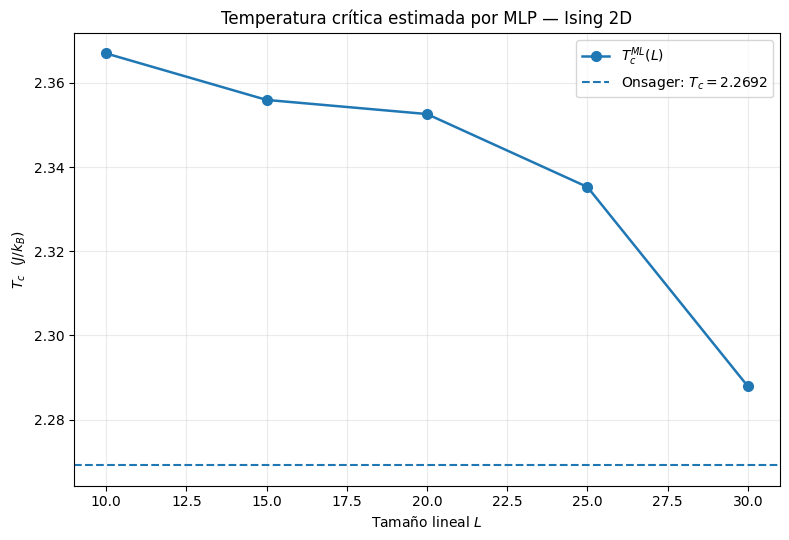

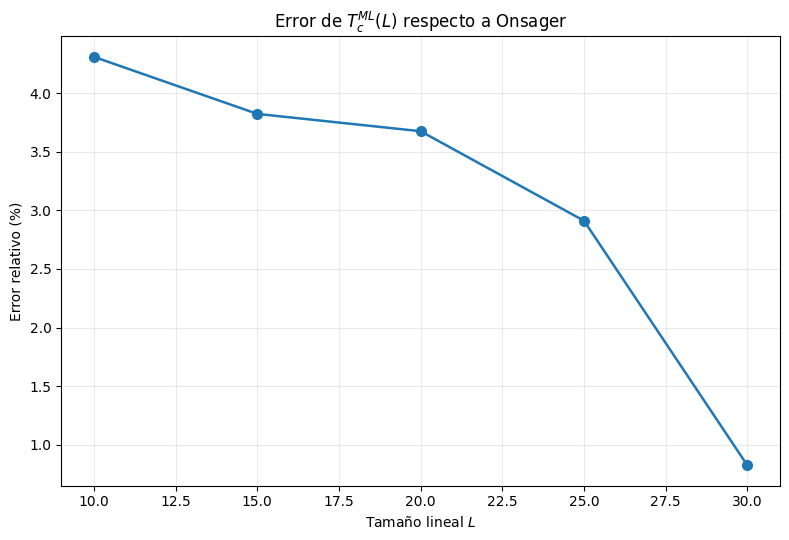

In [20]:
# ============================================================
# RESULTADO FINAL DEL RETO
# Comparación de Tc(L) con Onsager
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TC_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

# Tc obtenidas con el mismo procedimiento del Ejercicio 5:
# cruce de la probabilidad promedio P(desordenada|T) = 0.5

L_vals = np.array([10, 15, 20, 25, 30])

Tc_ML = np.array([
    2.366980,
    2.355936,
    2.352578,
    2.335242,
    2.287888
])

error_abs = np.abs(Tc_ML - TC_ONSAGER)
error_rel = 100 * error_abs / TC_ONSAGER

# ------------------------------------------------------------
# Tabla final
# ------------------------------------------------------------

tabla_final = pd.DataFrame({
    'L': L_vals,
    'N=L^2': L_vals**2,
    'Tc_ML': Tc_ML,
    'Tc_Onsager': TC_ONSAGER,
    'Error_absoluto': error_abs,
    'Error_relativo_%': error_rel
})

print("=" * 75)
print("RESULTADOS FINALES — RETO ISING 2D + MLP")
print("=" * 75)

display(tabla_final.round(6))

print()
print(f"Tc exacta de Onsager = {TC_ONSAGER:.8f}")

print()
print("Error relativo:")
for L, e in zip(L_vals, error_rel):
    print(f"L={L:2d}  ->  {e:.3f} %")


# ------------------------------------------------------------
# GRÁFICA 1 — Tc frente a L
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    L_vals,
    Tc_ML,
    'o-',
    linewidth=1.8,
    markersize=7,
    label=r'$T_c^{ML}(L)$'
)

ax.axhline(
    TC_ONSAGER,
    linestyle='--',
    linewidth=1.5,
    label=fr'Onsager: $T_c={TC_ONSAGER:.4f}$'
)

ax.set_xlabel('Tamaño lineal $L$')
ax.set_ylabel(r'$T_c$  ($J/k_B$)')

ax.set_title(
    'Temperatura crítica estimada por MLP — Ising 2D'
)

ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRÁFICA 2 — Error relativo frente a L
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    L_vals,
    error_rel,
    'o-',
    linewidth=1.8,
    markersize=7
)

ax.set_xlabel('Tamaño lineal $L$')
ax.set_ylabel('Error relativo (%)')

ax.set_title(
    r'Error de $T_c^{ML}(L)$ respecto a Onsager'
)

ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

#### Comparación de la temperatura crítica y efecto del tamaño finito

La temperatura crítica estimada por la red neuronal depende del tamaño finito
de la red de Ising. Los valores obtenidos fueron:

| $L$ | $T_c^{ML}(L)$ | Error relativo |
|---:|---:|---:|
| 10 | 2.366980 | 4.310 % |
| 15 | 2.355936 | 3.823 % |
| 20 | 2.352578 | 3.675 % |
| 25 | 2.335242 | 2.911 % |
| 30 | 2.287888 | 0.824 % |

El valor exacto de Onsager para el modelo de Ising bidimensional es

$$
T_c(\infty)=\frac{2}{\ln(1+\sqrt{2})}
\approx 2.269185\,\frac{J}{k_B}.
$$

Los resultados muestran que la estimación obtenida mediante el MLP se acerca
progresivamente al valor de Onsager a medida que aumenta el tamaño de la red.
Para $L=10$ el error relativo es aproximadamente $4.31\%$, mientras que para
$L=30$ disminuye hasta aproximadamente $0.82\%$.

Este comportamiento puede relacionarse con el **finite-size scaling**. En una
red finita la transición de fase no presenta exactamente el comportamiento del
límite termodinámico, por lo que se obtiene una pseudotemperatura crítica
$T_c(L)$ que depende del tamaño del sistema. Al aumentar $L$, los efectos de
tamaño finito disminuyen y $T_c(L)$ tiende hacia la temperatura crítica del
sistema infinito.

De manera general, el desplazamiento de la temperatura crítica puede escribirse
como

$$
|T_c(L)-T_c(\infty)|\sim L^{-1/\nu},
$$

donde $\nu$ es el exponente crítico asociado a la longitud de correlación.
Para el modelo de Ising 2D, $\nu=1$, por lo que asintóticamente se espera

$$
|T_c(L)-T_c(\infty)|\sim \frac{1}{L}.
$$

Los resultados obtenidos son consistentes cualitativamente con esta idea:
al aumentar el tamaño de la red disminuye el error respecto al valor de
Onsager. En particular, para $L=20$, solicitado en el ejercicio, se obtuvo

$$
\boxed{T_c^{ML}(20)=2.352578\,\frac{J}{k_B}},
$$

con un error relativo aproximado de $3.67\%$.

Por tanto, el MLP no solamente logra distinguir las fases ordenada y
desordenada del modelo de Ising, sino que su respuesta permite localizar la
región de transición y observar cómo la estimación de la temperatura crítica
se aproxima al límite termodinámico al aumentar el tamaño del sistema.